In [16]:
import random as rnd
import operator
import os
import time
import copy
import sys

# Data processing
import numpy as np                              # import numpy
import pandas as pd
import json
import scipy

# Plotting
import matplotlib.pyplot as plt                 # import matplotlib
import seaborn as sns
import matplotlib.colors as colors
import matplotlib as mpl
import matplotlib.ticker as tckr

# Custom packages for simulation
# This works only if notebooks folder is in the "modules" parent folder
sys.path.insert(0, '..') # add modules folder (parent folder) into this notebook's path

# Institution modules
import institutions.dm_bargain as dm_bargain
import institutions.dm_travel as dm_travel

# Environment modules
import environment.dm_agents as dm_agents
import environment.dm_env as env
import environment.env_make_agents as make_env

# Simulation modules
import simulations.dm_sim_period as simulate
import simulations.dm_sim as sim_utils

# Utility modules
import dm_utils as dm
import dm_process_results as results

# Latex module
import pylatex

# Import Agent Types from the agent definitions
ZIDPA = dm_agents.ZIDPA
ZID = dm_agents.ZID
ZIDP = dm_agents.ZIDP # Better comparison group - only difference is the movement strategy, not trade strategy
ZIDPR = dm_agents.ZIDPR

def print_agents(agents):
    for agent in agents:
        print(agent, type(agent))

def change_agents(agents, ratio=1):
    ZIDPR = dm_agents.ZIDPR
    """
    make a copy of agents at current location and change strategy to ZIDPR
    """

    # Pick a random set of agents to mutate (randomly at passed proportion - policy compliance rate)
    rn = np.random.default_rng()
    agent_indecies = list(range(len(agents)))
    complying_num = len(agents)*ratio
    non_int_part = complying_num%1
    add_num = 0
    if non_int_part != 0:
        # Randomly draw against remainder (keeps percetanges work across trials)
        if rn.random() < non_int_part:
            add_num += 1
            
    complying_num = int(complying_num) + add_num
    complying_inds = rn.choice(agent_indecies, size=complying_num)
    
    new_agents = []
    for k, agent in enumerate(agents):
        # change name
        if k in complying_inds: # These ones get Transformed
            name = agent.name
            s1 = name.split('_')
            name = s1[0] + '_' + s1[1] + '_ZIDPR'

            trader_type = agent.type
            payoff = agent.payoff
            money = agent.money
            location = agent.location
            lower_bound = agent.lower_bound
            upper_bound = agent.upper_bound
            move_error_rate = agent.movement_error_rate 
            # Added New
            cont_flag = agent.contract_this_period
            reset_flag_frequency = agent.reset_flag_frequency
            reset_flag_min_agents = agent.reset_flag_min_agents
            reset_flag_on_random = agent.reset_flag_on_random
            reset_flag_window = agent.reset_flag_window
            reset_flag_min_trades = agent.reset_flag_min_trades
            # make a ZIDPR agent
            new_agent = dm_agents.ZIDPR(name, trader_type, payoff, money, location, 
                                   lower_bound, upper_bound, move_error_rate, reset_flag_frequency, reset_flag_min_agents,
                                    reset_flag_on_random, reset_flag_window, reset_flag_min_trades)

            # For Week Flag Rule
            new_agent.trades_this_week = agent.trades_this_week
        
            # For Window flag Rule
            new_agent.current_period = agent.current_period
            new_agent.periods_traded_in = agent.periods_traded_in # test x1
            
            new_agent.set_contract_this_period(cont_flag)
        
            if new_agent.get_type() == "BUYER":
                vals = agent.get_values()
                new_agent.set_values(vals)
            else:
                cos = agent.get_costs()
                new_agent.set_costs(cos)
        else: # These ones do not
            new_agent = copy.deepcopy(agent)
            
        new_agents.append(new_agent)
        
    return new_agents

def change_back_agents(agents):
    
    ZIDPA = dm_agents.ZIDPA
    """Returns agents to type ZIDPA"""
    new_agents = []
    
    for k, agent in enumerate(agents):
        # change name
        name = agent.name
        s1 = name.split('_')
        name = s1[0] + '_' + s1[1] + '_ZIDPA'

        trader_type = agent.type
        payoff = agent.payoff
        money = agent.money
        location = agent.location
        lower_bound = agent.lower_bound
        upper_bound = agent.upper_bound
        cont_flag = agent.contract_this_period
        move_error_rate = agent.movement_error_rate 
        
        # Determine the rule (of thumb, here) by which to reset the flag for satisfaction with location (i.e. move or not)
        reset_flag_frequency = agent.reset_flag_frequency
        reset_flag_min_agents = agent.reset_flag_min_agents
        reset_flag_on_random = agent.reset_flag_on_random
        reset_flag_window = agent.reset_flag_window
        reset_flag_min_trades = agent.reset_flag_min_trades
        # make a ZIDPA agent
        new_agent = dm_agents.ZIDPA(name, trader_type, payoff, money, location, 
                                   lower_bound, upper_bound, move_error_rate, reset_flag_frequency, reset_flag_min_agents,
                                    reset_flag_on_random, reset_flag_window, reset_flag_min_trades)
        
        new_agent.set_contract_this_period(cont_flag)

        # For Week Flag Rule
        new_agent.trades_this_week = agent.trades_this_week
        
        # For Window flag Rule
        new_agent.current_period = agent.current_period
        new_agent.periods_traded_in = agent.periods_traded_in # test x1
        
        
        if new_agent.get_type() == "BUYER":
            vals = agent.get_values()
            new_agent.set_values(vals)
        else:
            cos = agent.get_costs()
            new_agent.set_costs(cos)
        
        new_agents.append(new_agent)
        
    return new_agents

# TODO redo adding data to the dataframe using CONCAT instead of building a long string and then adding - speed increase probable
def make_event_sim(sim_name, num_periods, num_weeks,
             event_begin, event_end, market, agents,
             num_rounds, grid_size,
             num_traders, num_units,
             lower_bound, upper_bound,
             trader_objects, movement_error_rate=0, compliance_rate=1, return_df=False, return_period_df=False, reset_flag_frequency=None, reset_flag_min_agents=None,
             reset_flag_on_random=False, reset_flag_window=None, reset_flag_min_trades=1):
    """Runs one complete simulation and returns data in
        effs[treatment][trial].  Causes epidemic event from event_begin to event_end
        return_df = True -> return as dataframe
    """ 

    if return_df:
        # Store parameters
        df_cols_param = ['sim_name', 'num_traders', 'num_units', 'num_weeks', 'num_periods', 'num_rounds', 'grid_size', 'lower_bound', 'upper_bound', 'trader_objects', 'movement_error_rate', 'compliance_rate', 
                         'event_bgin', 'event_end']
        # Store results
        df_cols_results = ['week', 'contracts', 'grids', 'eff', 'type_effs']
        df_cols = df_cols_param + df_cols_results
        df_data = []

    if return_period_df:
        if return_df:
            df_period_cols = df_cols + ['period'] + ['period_locs']
            df_period_data = []
        else:
            raise ValueError("Need to pass return_df=True with return_period_df=True")
    
    data = {}
    for week in range(num_weeks):
        
        if week == event_begin:
            agents = change_agents(agents, compliance_rate)
        if week == event_end:
            agents = change_back_agents(agents)
            
        data[week] = {}
        for agent in agents:
            agent.start(None)
        contracts = []
        sim_grids = []
        sim1 = simulate.SimPeriod(sim_name, num_rounds, agents, 
               market, grid_size)
        
        for period in range(num_periods):
            sim1.run_period()
            grid = sim1.get_grid()
            sim_grids.append(grid)
            contracts.extend(sim1.get_contracts())

            if return_period_df:
                if week == 0 and period == 0: # If you are at the first point in the simulation - save the initial grid at the week=-1, period=-1
                    period_data = [sim_name, num_traders, num_units, num_weeks, num_periods, num_rounds, grid_size, lower_bound, upper_bound, trader_objects, movement_error_rate, compliance_rate, event_begin, event_end, -1, 
                             (), copy.deepcopy(sim1.get_initial_grid()), None, None, -1, copy.deepcopy(sim1.get_initial_grid())]
                    df_period_data.append(period_data)

                period_data = [sim_name, num_traders, num_units, num_weeks, num_periods, num_rounds, grid_size, lower_bound, upper_bound, trader_objects, movement_error_rate, compliance_rate, event_begin, event_end, week, 
                         sim1.get_contracts(), grid, None, None, period, copy.deepcopy(grid)]
                df_period_data.append(period_data)
        
        data[week]['contracts'] = contracts
        data[week]['grids'] = sim_grids
        
        # process results
        pr1 = results.ProcessResults(market, sim_name, agents, contracts)
        pr1.calc_efficiency()
        pr1.get_results()
        eff = pr1.get_efficiency()
        type_eff = pr1.get_type_surplus()
        data[week]['eff'] = eff # single item put in list to faciliatate looping through data 
        data[week]['type_effs'] = type_eff

        if return_df:
            week_data = [sim_name, num_traders, num_units, num_weeks, num_periods, num_rounds, grid_size, lower_bound, upper_bound, trader_objects, movement_error_rate, compliance_rate, event_begin, event_end, week, 
                         contracts, sim_grids, eff, type_eff]
            df_data.append(week_data)

    if return_df:
        df_out = pd.DataFrame(data=df_data, columns=df_cols)
        if return_period_df:
            period_df_out = pd.DataFrame(data=df_period_data, columns=df_period_cols)
            return df_out, period_df_out
        else:
            return df_out
    else:
        return data


def make_event_monte_carlo(sim_name, num_trials, num_periods, num_weeks,
                    event_begin, event_end,
                    num_rounds, grid_size,
                    num_traders, num_units,
                    lower_bound, upper_bound,
                    trader_objects, movement_error_rate=0, compliance_rate=1, return_df=False, return_period_df=False, reset_flag_frequency=None, reset_flag_min_agents=None,
                    reset_flag_on_random=False, reset_flag_window=None, reset_flag_min_trades=1):
    """Runs one complete simulation and returns data in
        effs[treatment][trial]
        compliance_rate = ratio of agents complying with social distancing, e[0, 1]
        movement_error_rate = ratio of FULLY random moves, not employing strategy of movement, e[0, 1]
        return_df = True -> return as dataframe
    """ 

    sim_data = {}
    sim_data['parms'] = {'sim_name': sim_name, 'num_traders': num_traders, 'num_units': num_units,
                         'num_weeks': num_weeks, 'num_periods': num_periods, 'num_rounds': num_rounds,
                         'grid_size': grid_size, 'lower_bound':lower_bound, 'upper_bound': upper_bound,
                         'trader_objects': trader_objects, 'movement_error_rate': movement_error_rate, 'compliance_rate': compliance_rate}

    if return_df:
        # Store parameters
        df_cols_param = ['sim_name', 'num_traders', 'num_units', 'num_weeks', 'num_periods', 'num_rounds', 'grid_size', 'lower_bound', 'upper_bound', 'trader_objects', 'movement_error_rate', 'compliance_rate',
                        'event_begin', 'event_end']
        # Store outputs
        df_cols_results = ['week', 'contracts', 'grids', 'eff', 'type_effs']
        df_cols_trial = ['trial']
        df_cols = df_cols_param + df_cols_results + df_cols_trial
        df_out = pd.DataFrame(columns=df_cols)

    if return_period_df:
        if return_df:
            period_out_df = pd.DataFrame(columns=df_out.columns)
        else:
            raise ValueError("Need to be in return_df=True mode to get period details")
        
    # Run n trials of this setup
    for trial in range(num_trials):

        agent_maker = make_env.MakeAgents(num_traders, trader_objects, num_units, 
                                            grid_size, lower_bound, upper_bound, False, movement_error_rate, reset_flag_frequency=reset_flag_frequency, 
                                            reset_flag_min_agents=reset_flag_min_agents, reset_flag_on_random=reset_flag_on_random, reset_flag_window=reset_flag_window, 
                                          reset_flag_min_trades=reset_flag_min_trades)
        agent_maker.make_agents()
        agent_maker.set_locations(grid_size)
        agents = agent_maker.get_agents()

        # set up market
        agent_maker.make_market(sim_name)
        market = agent_maker.get_market()

        if not return_period_df: # If only want the week-by-week results
            trial_data = make_event_sim(sim_name, num_periods, num_weeks, 
                                        event_begin, event_end, market, agents,
                                        num_rounds, grid_size,
                                        num_traders, num_units,
                                        lower_bound, upper_bound,
                                        trader_objects, movement_error_rate, compliance_rate, return_df, reset_flag_frequency=reset_flag_frequency, 
                                            reset_flag_min_agents=reset_flag_min_agents, reset_flag_on_random=reset_flag_on_random, reset_flag_window=reset_flag_window, 
                                        reset_flag_min_trades=reset_flag_min_trades)
        else: # If want the period-by-period results
            trial_data, trial_period_data = make_event_sim(sim_name, num_periods, num_weeks, 
                            event_begin, event_end, market, agents,
                            num_rounds, grid_size,
                            num_traders, num_units,
                            lower_bound, upper_bound,
                            trader_objects, movement_error_rate, compliance_rate, return_df, return_period_df, reset_flag_frequency=reset_flag_frequency, 
                                            reset_flag_min_agents=reset_flag_min_agents, reset_flag_on_random=reset_flag_on_random, reset_flag_window=reset_flag_window, 
                                                           reset_flag_min_trades=reset_flag_min_trades)
            
        sim_data[trial] = trial_data

        if return_df:
            trial_data['trial'] = trial
            if len(df_out) == 0:
                df_out = trial_data
            else:
                df_out = pd.concat([df_out, trial_data], ignore_index=True)
                
        if return_period_df:
            trial_period_data['trial'] = trial
            if len(period_out_df) == 0:
                period_out_df = trial_period_data
            else:
                period_out_df = pd.concat([period_out_df, trial_period_data], ignore_index=True)
    
    if return_df:
        df_out = df_out.reset_index(drop=True)
        df_out['num_trials'] = num_trials
        if return_period_df:
            period_out_df = period_out_df.reset_index(drop=True)
            period_out_df['num_trials'] = num_trials
            return df_out, period_out_df
        else:
            return df_out
    else:
        return sim_data


def format_df_for_boxplot(data_df, x_var, y_var, x_range=None):
    """Reformats dataframe to be a matrix of [[y_1, ..., y_n]], [[y_2, ..., y_n]], ...]; length = length of x; indexes correspond to x's; for use in the box-plotting functions
        x_range (iterable): If using non-numeric x, need to specify a custom range for these, as the function cannot otherwise parse the data range.
    """

    matrix_out = []
    
    # If not provided, figure out x-range
    if x_range is None:
        x_min = data_df[x_var].min()
        x_max = data_df[x_var].max()
        x_range = range(x_min, x_max+1)

    # Traverse the dataframe
    for x in x_range:
        x_match = data_df[data_df[x_var]==x]
        y_vals = list(x_match[y_var].values)
        this_row = y_vals
        matrix_out.append(this_row)
    
    return matrix_out

In [17]:
def avg_df_obs(df_data, x_var, y_var, form="mean", percentiles=None):
    """Return the central tendency of the y_var observations, grouped on the x_var.
        form = mean or median
        percentiles (list) = None or list of percentiles to return
    """

    grouped = df_data[[x_var, y_var]].groupby(x_var)

    # Calc mean
    if form == "mean":
        df_out = grouped.mean()

    # Calc median
    elif form == "median":
        df_out = grouped.median()
        
    # Calc percentiles
    if percentiles is not None:
        for perc in percentiles:
            colname = y_var + "_q_" + str(perc)
            perc_frame = grouped.quantile(q=perc)
            perc_frame = perc_frame.rename(columns={y_var: colname})
            df_out = df_out.join(perc_frame)
    
    return df_out.reset_index()

In [18]:
def compare_graph(dfs, x_var="week", y_var="eff", form="line", form_type="mean", line_labs=None, title=None, x_ticks=None, x_tick_labs=None, x_name=None, y_name=None):
    """If not line_labs list provided, uses the names of the simulations in the dataframes. Pass the line lab as the treatments you want, and name the simulations accoring to these label names as well."""

    if line_labs is None:
        line_labs = []
        for i in range(len(dfs)):
            line_labs.append(dfs[i]["sim_name"].values[0])

    if x_tick_labs is None and x_ticks is not None:
        x_tick_labs = x_ticks

    plt.figure()
    plt.title(title)
    if x_name is None:
        x_name = x_var.capitalize()
    if y_name is None:
        y_name = y_var.capitalize
    plt.xlabel(x_name)
    plt.ylabel(y_name)

    if x_ticks is not None:
        if x_tick_labs is not None:
            plt.xticks(ticks=x_ticks, labels=x_tick_labs)
        else:
            plt.xticks(ticks=x_ticks)
    elif x_tick_labs is not None:
        plt.xticks(labels=x_tick_labs)
    
    if line_labs is not None:
        treat_names = line_labs
    else:
        treat_names = dfs.sim_name.unique()

    for i in range(len(treat_names)):
        this_lab = treat_names[i]
        this_df = dfs[dfs['sim_name']==this_lab]
        mean_df = avg_df_obs(this_df, x_var, y_var, form_type)
        plt.plot(mean_df[x_var], mean_df[y_var], label=this_lab)
    
    plt.legend()
    plt.show()
    

In [19]:
def three_d_grid(grid_size):
    """Transforms a grid size into a projected-vector 3d grid - represented as a nm and mn vectors"""    
    # create dimmensions - currently only for square grid of nXn
    colnames = ['D1', 'D2']
    grid_base = []
    n = np.arange(grid_size)
    m = np.arange(grid_size)
    for n1 in n:
        for m1 in m:
            grid_base.append([n1, m1])

    grid_df = pd.DataFrame(data=grid_base, columns=colnames)
    return grid_df

def plottable_locs(locs, grid_df, investigated="agents"):
    """Plots a location-agents dictionary onto a 3d grid based projects vectors"""
    grid_new = grid_df.copy()
    grid_new[investigated] = 0
    for loc in locs.keys():
        agent_at_key = len(locs[loc])
        d1 = loc[0]
        d2 = loc[1]
        spot_ind = grid_new[(grid_new['D1'] == d1) & (grid_new['D2'] == d2)].index
        grid_new[investigated].iloc[spot_ind] = agent_at_key
    return grid_new

def collate_loc_plots(sim_df, investigated="agents"):
    """Create large stacked DF with agent locations for every trial, week, and period
        sim_df: dataframe of results
        investigated: the value to report in the collated plotted grid df
        
        returns:
            dataframe of stacked form with the grid and observed vars at the points per trial, week, period
    """
    num_trials = sim_df['num_trials'].loc[0]
    num_weeks = sim_df['num_weeks'].loc[0]
    num_periods = sim_df['num_periods'].loc[0]
    num_rounds = sim_df['num_rounds'].loc[0]
    grid_size = sim_df['grid_size'].loc[0]
    num_traders = sim_df['grid_size'].loc[0]

    grd = three_d_grid(grid_size)
    
    control_cols = ['num_trials', 'num_weeks', 'num_periods', 'num_rounds', 'grid_size', 'num_traders', 'num_units', 'lower_bound', 'upper_bound']
    rel_df = sim_df[list(set(sim_df.columns) - set(control_cols))]

    out_df = pd.DataFrame()

    # Traverse the simulation df and save stacked plots
    for trial in range(num_trials):
        trial_df = rel_df[rel_df['trial']==trial]
        init_ind = trial_df[(trial_df['week']==-1) & (trial_df['period']==-1)].index
        init_loc = trial_df['period_locs'].loc[init_ind].values[0]
        init_plot = plottable_locs(init_loc, grd)
        init_plot['trial'] = trial
        init_plot['week'] = -1
        init_plot['period'] = -1
        out_df = pd.concat([out_df, init_plot], ignore_index=True)
        for week in range(num_weeks):
            week_df = trial_df[trial_df['week']==week]
            for period in range(num_periods):
                per_ind = week_df[week_df['period']==period].index
                per_loc = week_df['period_locs'].loc[per_ind].values[0]
                per_plot = plottable_locs(per_loc, grd)
                per_plot['trial'] = trial
                per_plot['week'] = week
                per_plot['period'] = period
                out_df = pd.concat([out_df, per_plot], ignore_index=True)

    return out_df

def graph_plotted(plotted, title_val=None, hue_val="agents", hue_norm_val=(0, 1), size_val="agent", size_norm_val=(0, 1), legend=False, palette="hot_r",
                 integer_bar=True, subtitle=False):
    """Visualize the data on a 2D grid to show the locations and values of the investigated value"""
    
    g = sns.relplot(
        data=plotted,
        x="D1", y="D2", hue=hue_val, size=size_val,
        palette=palette, hue_norm=hue_norm_val, edgecolor=".7",
        height=10, sizes=(35, 400), size_norm=size_norm_val, legend=False
    )

    if not subtitle:
        subtitle = ""
    
    # Tweak the figure to finalize
    g.set(xlabel=subtitle, ylabel="", aspect="equal", xticks=[], yticks=[], xticklabels=[], yticklabels=[], title=title_val)
    g.despine(left=True, bottom=True)
    g.ax.margins(.03)
    plt.grid()

    if legend:
        bar = g.figure.colorbar(mpl.cm.ScalarMappable(norm=hue_norm_val, cmap=palette),
             ax=plt.gca(), label=hue_val, aspect=100, shrink=0.8)
        
        if integer_bar:
            bar.locator = tckr.MaxNLocator(integer=True)
        

    return g

import warnings
import moviepy.video.io.ImageSequenceClip
from PIL import Image, ImageFile
# import PIL and PIL.ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

default_movie_stem = "loc_movie"
default_graph_folder = "loc_plots"
if not os.path.isdir(default_graph_folder):
    os.mkdir(default_graph_folder)

def to_len_str(number, str_len):
    base_str = str(number)
    new_str = '0'*(str_len-len(base_str)) + base_str
    return new_str

def movie_plotted(collated_plotted, movie_name=None, graph_folder=None, title_val=None, hue_val="Agents", size_val="Agents", scale="relative", hue_max=None, 
                  size_max=None, week_max=None, period_max=None, include_init=True, fps=1, subtitle=True):
    """
    collated_plotted: one trial (or an average of trials) plotted using 
    movie_name: The name to save the movie under (if not provided - uses default for the notebook + timestamp)
    graph_folder: The name of the folder to save the graphs in (if not provided - uses default for the notebook + new folder timestamp)
    title_val: what title to use
    hue_val: what to place the hue on
    size_val: what to place size on
    scale: the way in which normalization will be applied to graph hues and sizes
    hue_max: used for normalization of hue in absolute scale case
    size_max: used for normalization of size in absolute scale case
    """
    timestamp = int(time.time()*1000000) # integer to not have issues with os
    if graph_folder is None:
        graph_folder = default_graph_folder + "/plots_" + str(timestamp)
    else:
        graph_folder = default_graph_folder + "/" + graph_folder
        
    if movie_name is None:
        movie_name = graph_folder + "/movie.mp4"
    else:
        movie_name = graph_folder + "/" + movie_name
        
    if scale == "absolute":
        if hue_max is None:
            raise ValueError("Hue max must be defined for absolute scaling")
        if size_max is None:
            raise ValueError("Size max must be defined for absolute scaling")
    elif scale == "relative":
        hue_max = np.max(collated_plotted[hue_val])
        size_max = np.max(collated_plotted[size_val])
        
    hue_norm = colors.Normalize(vmin=0, vmax=hue_max)
    size_norm = colors.Normalize(vmin=0, vmax=size_max)
    
    # Check if directories exists
    if not os.path.isdir(graph_folder):
        os.mkdir(graph_folder)

    if os.path.isfile(movie_name):
        warnings.warn("Movie name already used")
        return
        # raise ValueError("Movie name already used")

    if week_max is None:
        week_max = np.max(collated_plotted['week'])

    week_digits = len(str(week_max))

    if period_max is None:
        period_max = np.max(collated_plotted['period'])

    period_digits = len(str(week_max))

    img_names = []
    if include_init:
        init_plot = collated_plotted[(collated_plotted['week']==-1) & (collated_plotted['period']==-1)]
        init_name = graph_folder + "/init_plot.png"
        img_names.append(init_name)
        if subtitle:
                subtitle = "Initial Position"
        init_graph = graph_plotted(init_plot, title_val=title_val, hue_val=hue_val, hue_norm_val=hue_norm, size_val=size_val, size_norm_val=size_norm, 
                                   legend=True, subtitle=subtitle)
        plt.savefig(init_name)
        plt.close()
    
    for week in range(0, week_max+1):
        for period in range(0, period_max+1):
            this_plot = collated_plotted[(collated_plotted['week']==week) & (collated_plotted['period']==period)]
            weekstr = to_len_str(week, week_digits)
            prdstr = to_len_str(period, period_digits)
            this_image_name = graph_folder + "/w" + weekstr + "p" + prdstr + "_plot.png"
            img_names.append(this_image_name)
            if subtitle:
                subtitle = "Week: "+weekstr+"; Period: "+prdstr
            
            this_graph = graph_plotted(this_plot, title_val=title_val, hue_val=hue_val, hue_norm_val=hue_norm, size_val=size_val, size_norm_val=size_norm,
                                      legend=True, subtitle=subtitle)
            plt.savefig(this_image_name)
            plt.close()
            

    # Create movie out of plotted graphs
    fps = fps
    clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(img_names, fps=fps)
    clip.write_videofile(movie_name)



In [20]:
def prepend_str(prepend_int):
    bs_str = str(prepend_int)
    if len(bs_str) == 1:
        r_str = "000" + bs_str
    elif len(bs_str) == 2:
        r_str = "00" + bs_str
    elif len(bs_str) == 3:
        r_str = "0" + bs_str
    else:
        r_str = bs_str
        
    return r_str

In [21]:
def create_fname(num_weeks, movement_error_rate, compliance_rate, reset_freq, flag_specific, on_random, 
                                          event_begin, event_end, title_prepend, folder="flag_reset_comparison", min_agents=None, window_size=None,min_trades=None):
    if min_agents is None:
        min_agents = 2
    if window_size is None:
        window_size = 7
    if min_trades is None:
        min_trades = 1
        
    if reset_freq == "MIN_AGENTS" and flag_specific is not None:
        min_agents = flag_specific
    elif reset_freq == "WEEK" and flag_specific is not None:
        min_trades = flag_specific
    elif reset_freq == "WINDOW" and flag_specific is not None:
        window_size = flag_specific[0]
        min_trades = flag_specific[1]

    tlt_append = ""
    fn_append = ""
    if movement_error_rate > 0:
        tlt_append = f"\nFlagOnRandom: {on_random}"
        fn_append = f"_fr_{str(on_random)[0]}"
    
    if reset_freq is None or reset_freq == "START" or reset_freq == "PERIOD":
        fn_1 = f"fr_{reset_freq}_er_{movement_error_rate}_cr_{compliance_rate}_t1" + fn_append + ".png"
        fn_10 = f"fr_{reset_freq}_er_{movement_error_rate}_cr_{compliance_rate}_t10" + fn_append + ".png"
    elif reset_freq == "MIN_AGENTS":
        fn_1 = f"fr_{reset_freq}_ma_{min_agents}_er_{movement_error_rate}_cr_{compliance_rate}_t1" + fn_append + ".png"
        fn_10 = f"fr_{reset_freq}_ma_{min_agents}_er_{movement_error_rate}_cr_{compliance_rate}_t10" + fn_append + ".png"
    elif reset_freq == "WEEK":
        fn_1 = f"fr_{reset_freq}_mt_{min_trades}_er_{movement_error_rate}_cr_{compliance_rate}_t1" + fn_append + ".png"
        fn_10 = f"fr_{reset_freq}_mt_{min_trades}_er_{movement_error_rate}_cr_{compliance_rate}_t10" + fn_append + ".png"
    elif reset_freq == "WINDOW":
        window_size = flag_specific[0]
        min_trades = flag_specific[1]
        fn_1 = f"fr_{reset_freq}_mt_{min_trades}_ws_{window_size}_er_{movement_error_rate}_cr_{compliance_rate}_t1" + fn_append + ".png"
        fn_10 = f"fr_{reset_freq}_mt_{min_trades}_ws_{window_size}_er_{movement_error_rate}_cr_{compliance_rate}_t10" + fn_append + ".png"

    if title_prepend is not None:
        fn_1 = title_prepend + fn_1
        fn_10 = title_prepend + fn_10

    return fn_1, fn_10
    

In [22]:
def plot_boxplot_data(boxplot_data, title=None, y_lab=None, x_lab=None, x_ticks=None, x_tick_labs=None, rbars=None, savename=None, fig_text=None,
                      xlim=None, ylim=None, figsize=None, colors=None, labels=None, legend=False, n=1):
    
    # If list, check length
    if n == 1:       
        boxplot_data = [boxplot_data]
    
    if figsize is None:
        figsize = (8,8)

    if colors is None and n!=1:
        cmap = plt.get_cmap("rainbow")
        colors = [cmap(i / (n - 1)) for i in range(n)]
    elif n!=1 and len(boxplot_data) != len(colors):
        raise ValueError(f"List of colors ({len(colors)}) and data ({len(boxplot_data)}) are not of the same length.")
    
    if labels is None and n!=1:
        base_str = "Series "
        labels = [base_str+str(x) for x in range(n)]
    elif n!=1 and len(labels) != len(boxplot_data):
        raise ValueError(f"List of labels ({len(colors)}) and data ({len(boxplot_data)}) are not of the same length.")

    fig, ax1 = plt.subplots(figsize=(figsize[0], figsize[1]))
    fig.canvas.manager.set_window_title('Boxplot')
    fig.subplots_adjust(left=0.075, right=0.95, top=0.9, bottom=0.25)
    
    # With one data series, plot in black+red
    if n == 1:
        bp = ax1.boxplot(boxplot_data[0], notch=True, sym='+', vert=1, whis=1.5)
        plt.setp(bp['boxes'], color='black')
        plt.setp(bp['whiskers'], color='black')
        plt.setp(bp['fliers'], color='red', marker='+')
    else:
        for i in range(n):
            bp = ax1.boxplot(boxplot_data[i], notch=True, sym='+', whis=1.5) # orientation='vertical',
            plt.setp(bp['boxes'], color=colors[i], label=labels[i])
            plt.setp(bp['whiskers'], color=colors[i])
            plt.setp(bp['fliers'], color=colors[i], marker='+')

        
    # Add a horizontal grid to the plot, but make it very light in color
    # so we can use it for reading data values but not be distracting
    ax1.yaxis.grid(True, linestyle='-', which='major', color='lightgrey',
                   alpha=0.5)
    
    ax1.set(
        axisbelow=True,  # Hide the grid behind plot objects
        title="Distribution of Weekly Efficiencies Across Trials",
        xlabel="Weeks",
        ylabel='Efficiency',
    )

    if legend == True:
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(by_label.values(), by_label.keys())

    if title is not None:
        ax1.set(title=title)

    if y_lab is not None:
        ax1.set(ylabel=y_lab)

    if x_lab is not None:
        ax1.set(xlabel=x_lab)

    if x_ticks is not None:
        ax1.set_xticks(x_ticks)

    if x_tick_labs is not None:
        ax1.set_xticklabels(x_tick_labs, fontsize=12)

    # Override standard tick labels with provided x_ticks if x_tick_labs not provided
    if x_ticks is not None and x_tick_labs is None:
        ax1.set_xticklabels(x_ticks, fontsize=12)

    if rbars is not None:
        plt.axvspan(rbars[0], rbars[1], color="grey", alpha=0.3)

    if xlim is not None:
        plt.xlim(xlim[0], xlim[1])

    if ylim is not None:
        plt.ylim(ylim[0], ylim[1]) 

    if fig_text is not None:
        plt.figtext(1, 0.2, fig_text)

    if savename is not None:
        plt.savefig(savename)
    else:
        plt.show()
    plt.clf()

In [23]:
def compare_flags(num_weeks=100, movement_error_rate=0, compliance_rate=1, reset_freq=None, flag_specific=None, on_random=False, 
                 event_begin=48, event_end=52, title_prepend=None, folder="flag_reset_comparison", num_agents=20, trader_objects=None,
                 min_agents=None, window_size=None, min_trades=None, num_periods=None, num_rounds=None, grid_size=None, num_units=None,lower_bound=None, upper_bound=None):
    ZIDPA = dm_agents.ZIDPA
    
    if min_agents is None:
        min_agents = 2
    if window_size is None:
        window_size = 7
    if min_trades is None:
        min_trades = 1

    if reset_freq == "MIN_AGENTS" and flag_specific is not None:
        min_agents = flag_specific
    elif reset_freq == "WEEK" and flag_specific is not None:
        min_trades = flag_specific
    elif reset_freq == "WINDOW" and flag_specific is not None:
        window_size = flag_specific[0]
        min_trades = flag_specific[1]

    num_trials = 1
    if num_periods is None:
        num_periods = 7
    if num_rounds is None:
        num_rounds = 5
    if grid_size is None:
        grid_size = 15
    num_traders = num_agents
    if lower_bound is None:
        lower_bound = 200
    if upper_bound is None:
        upper_bound = 600
    if grid_size is None:
        grid_size = 15
    if num_units is None:
        num_units = 8
    
    if trader_objects is None:
        trader_objects =[(ZIDPA, num_agents)]

    common_controls = [event_begin, event_end,
                        num_rounds, grid_size,
                        num_traders, num_units,
                        lower_bound, upper_bound,
                        trader_objects]

    tlt_append = ""
    fn_append = ""
    if movement_error_rate > 0:
        tlt_append = f"\nFlagOnRandom: {on_random}"
        fn_append = f"_fr_{str(on_random)[0]}"
    
    if reset_freq is None or reset_freq == "START" or reset_freq == "PERIOD":
        tlt = f"FlagRule: {reset_freq}.\nMoveErrorRate: {movement_error_rate}. ComplianceRate: {compliance_rate}." + tlt_append
        fn_1 = f"fr_{reset_freq}_er_{movement_error_rate}_cr_{compliance_rate}_t1" + fn_append + ".png"
        fn_10 = f"fr_{reset_freq}_er_{movement_error_rate}_cr_{compliance_rate}_t10" + fn_append + ".png"
    elif reset_freq == "MIN_AGENTS":
        tlt = f"FlagRule: {reset_freq}. MinAgents: {min_agents}.\nMoveErrorRate: {movement_error_rate}. ComplianceRate: {compliance_rate}." + tlt_append
        fn_1 = f"fr_{reset_freq}_ma_{min_agents}_er_{movement_error_rate}_cr_{compliance_rate}_t1" + fn_append + ".png"
        fn_10 = f"fr_{reset_freq}_ma_{min_agents}_er_{movement_error_rate}_cr_{compliance_rate}_t10" + fn_append + ".png"
    elif reset_freq == "WEEK":
        tlt = f"FlagRule: {reset_freq}. MinTrades: {min_trades}.\nMoveErrorRate: {movement_error_rate}. ComplianceRate: {compliance_rate}." + tlt_append
        fn_1 = f"fr_{reset_freq}_mt_{min_trades}_er_{movement_error_rate}_cr_{compliance_rate}_t1" + fn_append + ".png"
        fn_10 = f"fr_{reset_freq}_mt_{min_trades}_er_{movement_error_rate}_cr_{compliance_rate}_t10" + fn_append + ".png"
    elif reset_freq == "WINDOW":
        window_size = flag_specific[0]
        min_trades = flag_specific[1]
        tlt = f"FlagRule: {reset_freq}. MinTrades: {min_trades}. Window: {window_size}.\nMoveErrorRate: {movement_error_rate}. ComplianceRate: {compliance_rate}." + tlt_append
        fn_1 = f"fr_{reset_freq}_mt_{min_trades}_ws_{window_size}_er_{movement_error_rate}_cr_{compliance_rate}_t1" + fn_append + ".png"
        fn_10 = f"fr_{reset_freq}_mt_{min_trades}_ws_{window_size}_er_{movement_error_rate}_cr_{compliance_rate}_t10" + fn_append + ".png"

    if title_prepend is not None:
        fn_1 = title_prepend + fn_1
        fn_10 = title_prepend + fn_10
    
    trial_1 = make_event_monte_carlo("test1", num_trials, num_periods, num_weeks, *common_controls, movement_error_rate, compliance_rate, return_df=True, 
                                     reset_flag_frequency=reset_freq, reset_flag_min_agents=min_agents, reset_flag_on_random=on_random,
                                     reset_flag_window=window_size, reset_flag_min_trades=min_trades)
    plt.plot(trial_1['eff'])
    plt.axvspan(event_begin-0.5, event_end+0.5, color="grey", alpha=0.3)
    plt.title(tlt)
    plt.xlabel("Week")
    plt.ylabel("Efficiency")
    plt.savefig(folder+"/"+fn_1)
    plt.clf()

    num_trials = 10

    trial_10 = make_event_monte_carlo("test10", num_trials, num_periods, num_weeks, *common_controls, movement_error_rate, compliance_rate, return_df=True, 
                                      reset_flag_frequency=reset_freq, reset_flag_min_agents=min_agents, reset_flag_on_random=on_random,
                                      reset_flag_window=window_size, reset_flag_min_trades=min_trades)
    
    td_boxplot = format_df_for_boxplot(trial_10, 'week', 'eff')
    
    #plt.axvspan(event_begin, event_end, color="grey", alpha=0.3)

    incr = 10
    if num_weeks == 500:
        incr = 40

    svn = folder+"/"+fn_10
    plot_boxplot_data(td_boxplot, title=tlt, y_lab="Efficiency", x_lab="Week", x_ticks=np.arange(0, num_weeks+1, incr), rbars=(event_begin-0.5, event_end+0.5),
                     savename=svn)


In [24]:
def calc_area_under_curve(simulation_df):
    """Calculates the area under the curve = sum of efficiencies/sum(max efficiencies) for a particular run or set of runs - returns 1 number or df of trials: areas"""
    num_trials = simulation_df['num_trials'].valuess[0]
    if num_trials == 1:
        return simulation_df['eff'].sum()/(simulation_df['num_weeks']*100)
    else:
        ret_df = simulation_df.groupby('trial').sum('eff')/(simulation_df['num_weeks']*100)
        return ret_df

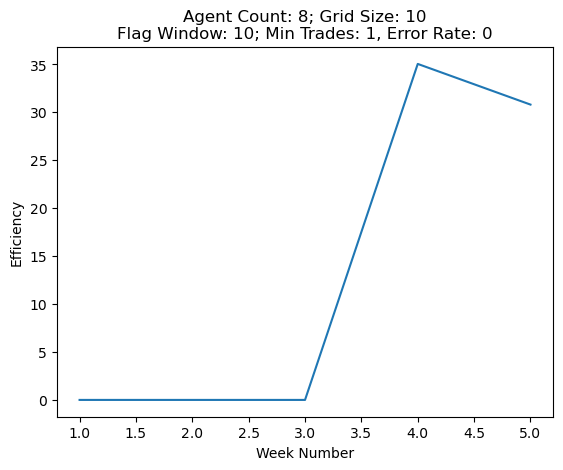

Number of Trials: 1
Number of Periods (Days): 7
Number of Weeks: 5
Event Begin: 100000000
Event End: 1000000
Number of Rounds (Trades/Day): 1
Grid Size: 10
Number of Traders: 8
Number of Units: 8
Lower Bound:200
Upper Bound: 600
Movement Error Rate: 0
Event Compliance Rate: 1
Reset Flag Rule: WINDOW
Flag Window Size: 7
Flag Min Agents: None
Flag Min Trades: 1


In [25]:

# Event begin and end at arbitrarily large number, so as to not have even trigger
num_trials = 1; num_periods = 7; num_weeks = 5; event_begin = 100000000; event_end = 1000000; num_rounds = 1; grid_size = 10; num_traders = 8; num_units = 8;
lower_bound = 200; upper_bound = 600
trader_objects =[(ZIDPA, 8),(ZID, 0)] # TODO: Need to make the num_traders and trader_objects be less onerous to work with
common_controls = [event_begin, event_end,
                    num_rounds, grid_size,
                    num_traders, num_units,
                    lower_bound, upper_bound,
                    trader_objects]

movement_error_rate = 0
compliance_rate = 1

reset_freq="WINDOW"
min_agents=None
on_random=False
window_size = 7
min_trades = 1

trial_1 = make_event_monte_carlo("test1", num_trials, num_periods, num_weeks, *common_controls, movement_error_rate, compliance_rate, return_df=True, 
                                 reset_flag_frequency=reset_freq, reset_flag_min_agents=min_agents, reset_flag_on_random=on_random,
                                 reset_flag_window=window_size, reset_flag_min_trades=min_trades)

plt.plot(trial_1['week']+1, trial_1['eff'])
plt.ylabel("Efficiency")
plt.xlabel("Week Number")
# plt.axvspan(event_begin-0.5, event_end+0.5, color="grey", alpha=0.3)
print()
ttl = f"Agent Count: {num_traders}; Grid Size: {grid_size}\nFlag Window: {grid_size}; Min Trades: {min_trades}, Error Rate: {movement_error_rate}"
plt.title(ttl)
txt_dsc = f"Number of Trials: {num_trials}\nNumber of Periods (Days): {num_periods}\nNumber of Weeks: {num_weeks}\nEvent Begin: {event_begin}\nEvent End: {event_end}\nNumber of Rounds (Trades/Day): {num_rounds}\nGrid Size: {grid_size}\nNumber of Traders: {num_traders}\nNumber of Units: {num_units}\nLower Bound:{lower_bound}\nUpper Bound: {upper_bound}\nMovement Error Rate: {movement_error_rate}\nEvent Compliance Rate: {compliance_rate}\nReset Flag Rule: {reset_freq}\nFlag Window Size: {window_size}\nFlag Min Agents: {min_agents}\nFlag Min Trades: {min_trades}"
#plt.figtext(1, 0.2, txt_dsc)
plt.show()
print(txt_dsc)

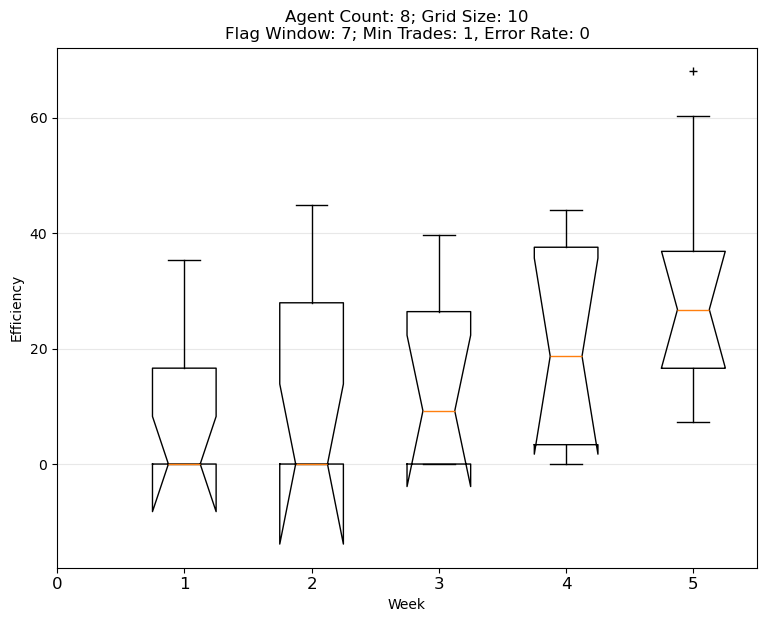

<Figure size 640x480 with 0 Axes>

Number of Trials: 10
Number of Periods (Days): 7
Number of Weeks: 5
Event Begin: 100000000
Event End: 1000000
Number of Rounds (Trades/Day): 1
Grid Size: 10
Number of Traders: 8
Number of Units: 8
Lower Bound:200
Upper Bound: 600
Movement Error Rate: 0
Event Compliance Rate: 1
Reset Flag Rule: WINDOW
Flag Window Size: 7
Flag Min Agents: None
Flag Min Trades: 1


In [26]:
num_trials = 10; num_periods = 7; num_weeks = 5; event_begin = 100000000; event_end = 1000000; num_rounds = 1; grid_size = 10; num_traders = 8; num_units = 8;
lower_bound = 200; upper_bound = 600
trader_objects =[(ZIDPA, 8),(ZID, 0)] # TODO: Need to make the num_traders and trader_objects be less onerous to work with
common_controls = [event_begin, event_end,
                    num_rounds, grid_size,
                    num_traders, num_units,
                    lower_bound, upper_bound,
                    trader_objects]

movement_error_rate = 0
compliance_rate = 1

reset_freq="WINDOW"
min_agents=None
on_random=False
window_size = 7
min_trades = 1

trial_10 = make_event_monte_carlo("test10", num_trials, num_periods, num_weeks, *common_controls, movement_error_rate, compliance_rate, return_df=True, 
                                 reset_flag_frequency=reset_freq, reset_flag_min_agents=min_agents, reset_flag_on_random=on_random,
                                 reset_flag_window=window_size, reset_flag_min_trades=min_trades)

ttl = f"Agent Count: {num_traders}; Grid Size: {grid_size}\nFlag Window: {window_size}; Min Trades: {min_trades}, Error Rate: {movement_error_rate}"

td_boxplot = format_df_for_boxplot(trial_10, 'week', 'eff')

incr = 1

plot_boxplot_data(td_boxplot, title=ttl, y_lab="Efficiency", x_lab="Week", x_ticks=np.arange(0, num_weeks+1, incr), rbars=None, savename=None)

txt_dsc = f"Number of Trials: {num_trials}\nNumber of Periods (Days): {num_periods}\nNumber of Weeks: {num_weeks}\nEvent Begin: {event_begin}\nEvent End: {event_end}\nNumber of Rounds (Trades/Day): {num_rounds}\nGrid Size: {grid_size}\nNumber of Traders: {num_traders}\nNumber of Units: {num_units}\nLower Bound:{lower_bound}\nUpper Bound: {upper_bound}\nMovement Error Rate: {movement_error_rate}\nEvent Compliance Rate: {compliance_rate}\nReset Flag Rule: {reset_freq}\nFlag Window Size: {window_size}\nFlag Min Agents: {min_agents}\nFlag Min Trades: {min_trades}"
#plt.figtext(1, 0.2, txt_dsc)
plt.show()
print(txt_dsc)

In [27]:
compare_week_grids_0  = False
if compare_week_grids_0:
    for wk in [5, 7, 10, 12, 16, 20]:
        for g_sz in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]:
            n_ag = 8
            num_trials = 10; num_periods = 7; num_weeks = wk; event_begin = 100000000; event_end = 1000000; num_rounds = 1; grid_size = g_sz; num_traders = n_ag; num_units = 8;
            lower_bound = 200; upper_bound = 600
            trader_objects =[(ZIDPA, n_ag),(ZID, 0)] # TODO: Need to make the num_traders and trader_objects be less onerous to work with
            common_controls = [event_begin, event_end,
                                num_rounds, grid_size,
                                num_traders, num_units,
                                lower_bound, upper_bound,
                                trader_objects]

            movement_error_rate = 0
            compliance_rate = 1

            reset_freq="WINDOW"
            min_agents=None
            on_random=False
            window_size = 7
            min_trades = 1

            trial_10 = make_event_monte_carlo("test10", num_trials, num_periods, num_weeks, *common_controls, movement_error_rate, compliance_rate, return_df=True, 
                                            reset_flag_frequency=reset_freq, reset_flag_min_agents=min_agents, reset_flag_on_random=on_random,
                                            reset_flag_window=window_size, reset_flag_min_trades=min_trades)

            ttl = f"Agent Count: {num_traders}; Grid Size: {grid_size}\nFlag Window: {window_size}; Min Trades: {min_trades}, Error Rate: {movement_error_rate}"

            td_boxplot = format_df_for_boxplot(trial_10, 'week', 'eff')

            incr = 1

            txt_dsc = f"Number of Trials: {num_trials}\nNumber of Periods (Days): {num_periods}\nNumber of Weeks: {num_weeks}\nEvent Begin: {event_begin}\nEvent End: {event_end}\nNumber of Rounds (Trades/Day): {num_rounds}\nGrid Size: {grid_size}\nNumber of Traders: {num_traders}\nNumber of Units: {num_units}\nLower Bound:{lower_bound}\nUpper Bound: {upper_bound}\nMovement Error Rate: {movement_error_rate}\nEvent Compliance Rate: {compliance_rate}\nReset Flag Rule: {reset_freq}\nFlag Window Size: {window_size}\nFlag Min Agents: {min_agents}\nFlag Min Trades: {min_trades}"

            sav_fold_g = "week_grid_tests"
            if not os.path.isdir(sav_fold_g):
                os.mkdir(sav_fold_g)
            sav_name_g = os.path.join(sav_fold_g, f"weeks_{wk}_gridsize_{g_sz}.png")

            plot_boxplot_data(td_boxplot, title=ttl, y_lab="Efficiency", x_lab="Week", x_ticks=np.arange(0, num_weeks+1, incr), rbars=None, savename=sav_name_g, fig_text=txt_dsc, ylim=[0, 100])

            #plt.figtext(1, 0.2, txt_dsc)
            # print(txt_dsc)

In [28]:
test_zidpa = False
if test_zidpa:
    n_ag = 8
    num_trials = 10; num_periods = 7; num_weeks = wk; event_begin = 100000000; event_end = 1000000; num_rounds = 1; grid_size = g_sz; num_traders = n_ag; num_units = 8;
    lower_bound = 200; upper_bound = 600
    trader_objects =[(ZIDPA, n_ag),(ZID, 0)] # TODO: Need to make the num_traders and trader_objects be less onerous to work with
    common_controls = [event_begin, event_end,
                        num_rounds, grid_size,
                        num_traders, num_units,
                        lower_bound, upper_bound,
                        trader_objects]

    movement_error_rate = 0
    compliance_rate = 1

    reset_freq="WINDOW"
    min_agents=None
    on_random=False
    window_size = 7
    min_trades = 1

    trial_10 = make_event_monte_carlo("test10", num_trials, num_periods, num_weeks, *common_controls, movement_error_rate, compliance_rate, return_df=True, 
                                    reset_flag_frequency=reset_freq, reset_flag_min_agents=min_agents, reset_flag_on_random=on_random,
                                    reset_flag_window=window_size, reset_flag_min_trades=min_trades)

    ttl = f"Agent Count: {num_traders}; Grid Size: {grid_size}\nFlag Window: {window_size}; Min Trades: {min_trades}, Error Rate: {movement_error_rate}"

    td_boxplot = format_df_for_boxplot(trial_10, 'week', 'eff')

    incr = 1

    txt_dsc = f"Number of Trials: {num_trials}\nNumber of Periods (Days): {num_periods}\nNumber of Weeks: {num_weeks}\nEvent Begin: {event_begin}\nEvent End: {event_end}\nNumber of Rounds (Trades/Day): {num_rounds}\nGrid Size: {grid_size}\nNumber of Traders: {num_traders}\nNumber of Units: {num_units}\nLower Bound:{lower_bound}\nUpper Bound: {upper_bound}\nMovement Error Rate: {movement_error_rate}\nEvent Compliance Rate: {compliance_rate}\nReset Flag Rule: {reset_freq}\nFlag Window Size: {window_size}\nFlag Min Agents: {min_agents}\nFlag Min Trades: {min_trades}"

    sav_fold_g = "type_comp_tests"
    if not os.path.isdir(sav_fold_g):
        os.mkdir(sav_fold_g)
    sav_name_g = os.path.join(sav_fold_g, f"zidpa.png")

    plot_boxplot_data(td_boxplot, title="ZIDPA", y_lab="Efficiency", x_lab="Week", x_ticks=np.arange(0, num_weeks+1, incr), rbars=None, savename=None, fig_text=txt_dsc, ylim=[0, 100])

    #plt.figtext(1, 0.2, txt_dsc)
    # print(txt_dsc)

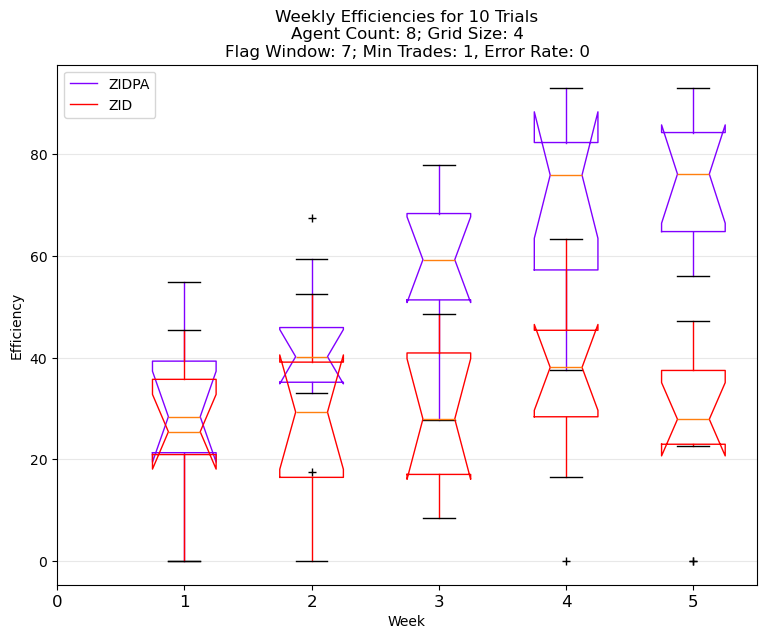

<Figure size 640x480 with 0 Axes>

In [29]:
num_trials = 10; num_periods = 7; num_weeks = 5; event_begin = 100000000; event_end = 1000000; num_rounds = 1; grid_size = 4; num_traders = 8; num_units = 8;
lower_bound = 200; upper_bound = 600

movement_error_rate = 0
compliance_rate = 1

reset_freq="WINDOW"
min_agents=None
on_random=False
window_size = 7
min_trades = 1

incr = 1

trader_objects =((ZIDPA, 8),(ZID, 0)) # TODO: Need to make the num_traders and trader_objects be less onerous to work with
txt_dsc = f"Number of Trials: {num_trials}\nNumber of Periods (Days): {num_periods}\nNumber of Weeks: {num_weeks}\nEvent Begin: {event_begin}\nEvent End: {event_end}\nNumber of Rounds (Trades/Day): {num_rounds}\nGrid Size: {grid_size}\nNumber of Traders: {num_traders}\nNumber of Units: {num_units}\nLower Bound:{lower_bound}\nUpper Bound: {upper_bound}\nMovement Error Rate: {movement_error_rate}\nEvent Compliance Rate: {compliance_rate}\nReset Flag Rule: {reset_freq}\nFlag Window Size: {window_size}\nFlag Min Agents: {min_agents}\nFlag Min Trades: {min_trades}\nTrader Objects: {trader_objects}"
#plt.figtext(1, 0.2, txt_dsc)
# print("Series 0\n"+txt_dsc+"\n\n")
s1 = make_event_monte_carlo("s1", num_trials, num_periods, num_weeks, event_begin, event_end,
                    num_rounds, grid_size,
                    num_traders, num_units,
                    lower_bound, upper_bound,
                    trader_objects, movement_error_rate, compliance_rate, return_df=True, 
                                 reset_flag_frequency=reset_freq, reset_flag_min_agents=min_agents, reset_flag_on_random=on_random,
                                 reset_flag_window=window_size, reset_flag_min_trades=min_trades)
s1_boxplot = format_df_for_boxplot(s1, 'week', 'eff')

trader_objects =((ZIDPA, 0),(ZID, 8))
txt_dsc = f"Number of Trials: {num_trials}\nNumber of Periods (Days): {num_periods}\nNumber of Weeks: {num_weeks}\nEvent Begin: {event_begin}\nEvent End: {event_end}\nNumber of Rounds (Trades/Day): {num_rounds}\nGrid Size: {grid_size}\nNumber of Traders: {num_traders}\nNumber of Units: {num_units}\nLower Bound:{lower_bound}\nUpper Bound: {upper_bound}\nMovement Error Rate: {movement_error_rate}\nEvent Compliance Rate: {compliance_rate}\nReset Flag Rule: {reset_freq}\nFlag Window Size: {window_size}\nFlag Min Agents: {min_agents}\nFlag Min Trades: {min_trades}\nTrader Objects: {trader_objects}"
# print("Series 1\n"+txt_dsc)
s2 = make_event_monte_carlo("s2", num_trials, num_periods, num_weeks, event_begin, event_end,
                    num_rounds, grid_size,
                    num_traders, num_units,
                    lower_bound, upper_bound,
                    trader_objects, movement_error_rate, compliance_rate, return_df=True, 
                                 reset_flag_frequency=reset_freq, reset_flag_min_agents=min_agents, reset_flag_on_random=on_random,
                                 reset_flag_window=window_size, reset_flag_min_trades=min_trades)
s2_boxplot = format_df_for_boxplot(s2, 'week', 'eff')

ttl = f"Weekly Efficiencies for {num_trials} Trials\nAgent Count: {num_traders}; Grid Size: {grid_size}\nFlag Window: {window_size}; Min Trades: {min_trades}, Error Rate: {movement_error_rate}"

plot_boxplot_data([s1_boxplot, s2_boxplot], title=ttl, y_lab="Efficiency", x_lab="Week", x_ticks=np.arange(0, num_weeks+1, incr), rbars=None, savename=None, legend=True, n=2, labels=["ZIDPA", "ZID"])

# plt.show()

In [30]:
compare_week_grids = False
if compare_week_grids:
    for wk in [5, 7, 10, 12, 16, 20]:
        for g_sz in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]:
            n_ag = 8
            num_trials = 10; num_periods = 7; num_weeks = wk; event_begin = 100000000; event_end = 1000000; num_rounds = 1; grid_size = g_sz; num_traders = n_ag; num_units = 8;
            lower_bound = 200; upper_bound = 600
            trader_objects =[(ZIDPA, n_ag),(ZID, 0)] # TODO: Need to make the num_traders and trader_objects be less onerous to work with
            common_controls = [event_begin, event_end,
                                num_rounds, grid_size,
                                num_traders, num_units,
                                lower_bound, upper_bound,
                                trader_objects]

            movement_error_rate = 0
            compliance_rate = 1

            reset_freq="WINDOW"
            min_agents=None
            on_random=False
            window_size = 7
            min_trades = 1

            trial_10 = make_event_monte_carlo("test10", num_trials, num_periods, num_weeks, *common_controls, movement_error_rate, compliance_rate, return_df=True, 
                                            reset_flag_frequency=reset_freq, reset_flag_min_agents=min_agents, reset_flag_on_random=on_random,
                                            reset_flag_window=window_size, reset_flag_min_trades=min_trades)

            ttl = f"Agent Count: {num_traders}; Grid Size: {grid_size}\nFlag Window: {window_size}; Min Trades: {min_trades}, Error Rate: {movement_error_rate}"

            td_boxplot = format_df_for_boxplot(trial_10, 'week', 'eff')

            incr = 1

            txt_dsc = f"Number of Trials: {num_trials}\nNumber of Periods (Days): {num_periods}\nNumber of Weeks: {num_weeks}\nEvent Begin: {event_begin}\nEvent End: {event_end}\nNumber of Rounds (Trades/Day): {num_rounds}\nGrid Size: {grid_size}\nNumber of Traders: {num_traders}\nNumber of Units: {num_units}\nLower Bound:{lower_bound}\nUpper Bound: {upper_bound}\nMovement Error Rate: {movement_error_rate}\nEvent Compliance Rate: {compliance_rate}\nReset Flag Rule: {reset_freq}\nFlag Window Size: {window_size}\nFlag Min Agents: {min_agents}\nFlag Min Trades: {min_trades}"

            sav_fold_g = "week_grid_tests"
            if not os.path.isdir(sav_fold_g):
                os.mkdir(sav_fold_g)
            sav_name_g = os.path.join(sav_fold_g, f"weeks_{wk}_gridsize_{g_sz}.png")

            plot_boxplot_data(td_boxplot, title=ttl, y_lab="Efficiency", x_lab="Week", x_ticks=np.arange(0, num_weeks+1, incr), rbars=None, savename=sav_name_g, fig_text=txt_dsc, ylim=[0, 100])

            #plt.figtext(1, 0.2, txt_dsc)
            # print(txt_dsc)

In [31]:
def extract_n(period_locs):
    """Return number of occupied points in period_locs dictionary"""
    if period_locs is None:
        return 0
    else:
        return len(period_locs)
    
def extract_h(period_locs, num_agents):
    """Return agent h based on period_locs dictionary"""
    if period_locs is None:
        return 0
    else:
        h = 0
        loc_vals = list(period_locs.values())
        for i in range(len(period_locs)):
            h += (len(loc_vals[i])/num_agents)**2

        return h

def agent_density(df_sim, by_period=False, return_df=False):

    num_agents = df_sim['num_traders'][0]

    if by_period: # if want to return by-period data
        try:
            df_sim['tr_period']
        except KeyError:
            raise ValueError("The df_sim must have a tr_period column if by_period=True")
        np_df = df_sim.copy()
        np_df['loc_occupied'] = np_df['period_locs'].apply(extract_n)
        np_df['agent_conct'] = np_df['period_locs'].apply(extract_h, args=[num_agents])

        # Calculate periods occupied point and agent h (herschfindal)
        if return_df:
            return np_df
        else:
            return np_df['loc_occupied'].values(), np_df['agent_conct'].values()


    else: # if want to return by-week data
        week_grids = df_sim['grids']
        week_len = df_sim['num_periods'][0]
        week_n = np.zeros(len(df_sim))
        week_h = np.zeros(len(df_sim))

        # Calculate average weekly occupied point and agent h (herschfindal)
        period_n = np.zeros(len(df_sim)*week_len)
        period_h = np.zeros(len(df_sim)*week_len)
        for i in range(len(week_grids)):
            week_grid = week_grids[i]
            for j in range(week_len):
                period_occupied = week_grid[j].values()
                period_grid = list(period_occupied)
                
                n_occupied = len(period_grid)
                agent_h = 0
                for k in range(n_occupied):
                    agent_h += (len(period_grid[k])/num_agents)**2
                period_n[i*week_len+j] = n_occupied
                period_h[i*week_len+j] = agent_h
            week_n[i] = np.mean(period_n[i*week_len:(i+1)*week_len])
            week_h[i] = np.mean(period_h[i*week_len:(i+1)*week_len])

        if return_df:
            week_df = pd.DataFrame()
            week_df['trial'] = df_sim['trial']
            week_df['week'] = df_sim['week']
            week_df['week_loc_occupied'] = week_n
            week_df['week_agent_conct'] = week_h
            return week_df
        else:
            return week_n, week_h

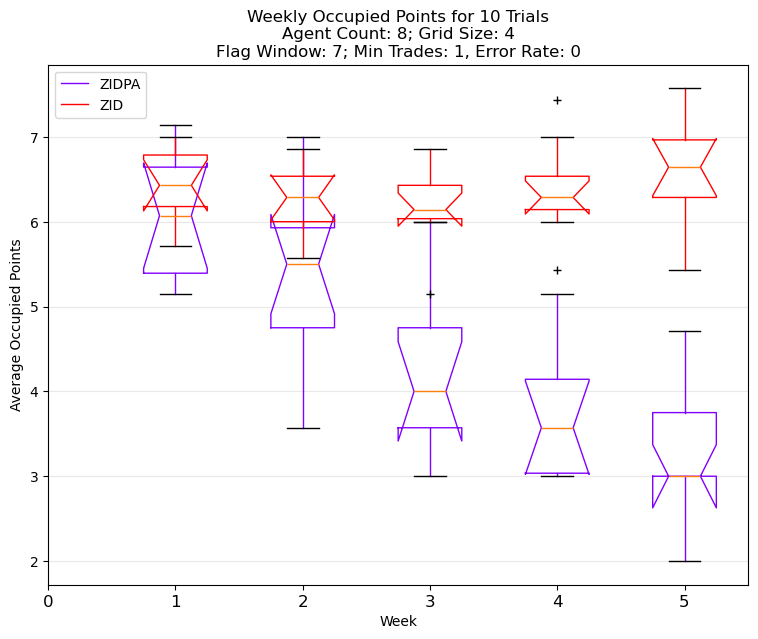

<Figure size 640x480 with 0 Axes>

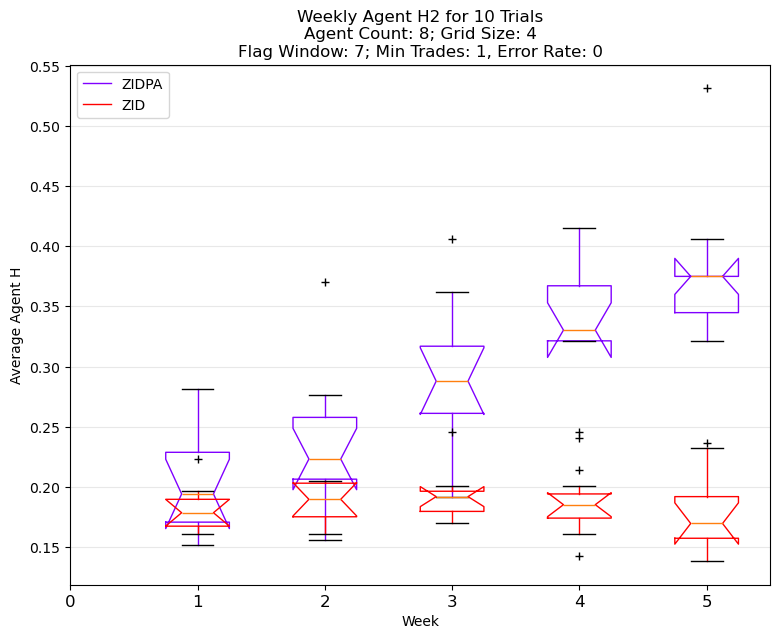

<Figure size 640x480 with 0 Axes>

In [32]:
occ_s1 = agent_density(s1, return_df=True)
td_occ_s1 = format_df_for_boxplot(occ_s1, 'week', 'week_loc_occupied')
td_h_s1 = format_df_for_boxplot(occ_s1, 'week', 'week_agent_conct')

occ_s2 = agent_density(s2, return_df=True)
td_occ_s2 = format_df_for_boxplot(occ_s2, 'week', 'week_loc_occupied')
td_h_s2 = format_df_for_boxplot(occ_s2, 'week', 'week_agent_conct')

ttl = f"Weekly Occupied Points for {num_trials} Trials\nAgent Count: {num_traders}; Grid Size: {grid_size}\nFlag Window: {window_size}; Min Trades: {min_trades}, Error Rate: {movement_error_rate}"
plot_boxplot_data([td_occ_s1, td_occ_s2], title=ttl, y_lab="Average Occupied Points", x_lab="Week", x_ticks=np.arange(0, num_weeks+1, incr), rbars=None, savename=None, legend=True, n=2, labels=["ZIDPA", "ZID"])

ttl = f"Weekly Agent H2 for {num_trials} Trials\nAgent Count: {num_traders}; Grid Size: {grid_size}\nFlag Window: {window_size}; Min Trades: {min_trades}, Error Rate: {movement_error_rate}"
plot_boxplot_data([td_h_s1, td_h_s2], title=ttl, y_lab="Average Agent H", x_lab="Week", x_ticks=np.arange(0, num_weeks+1, incr), rbars=None, savename=None, legend=True, n=2, labels=["ZIDPA", "ZID"])

In [33]:
num_trials = 10; num_periods = 7; num_weeks = 5; event_begin = 100000000; event_end = 1000000; num_rounds = 1; grid_size = 4; num_traders = 8; num_units = 8;
lower_bound = 200; upper_bound = 600

movement_error_rate = 0
compliance_rate = 1

reset_freq="WINDOW"
min_agents=None
on_random=False
window_size = 7
min_trades = 1

incr = 1

trader_objects =((ZIDPA, 8),(ZIDP, 0)) # TODO: Need to make the num_traders and trader_objects be less onerous to work with

s1, s1_p = make_event_monte_carlo("s1", num_trials, num_periods, num_weeks, event_begin, event_end,
                    num_rounds, grid_size,
                    num_traders, num_units,
                    lower_bound, upper_bound,
                    trader_objects, movement_error_rate, compliance_rate, return_df=True, 
                                 reset_flag_frequency=reset_freq, reset_flag_min_agents=min_agents, reset_flag_on_random=on_random,
                                 reset_flag_window=window_size, reset_flag_min_trades=min_trades, return_period_df=True)
#s1_boxplot = format_df_for_boxplot(s1, 'week', 'eff')

trader_objects =((ZIDPA, 0),(ZIDP, 8))

s2, s2_p = make_event_monte_carlo("s2", num_trials, num_periods, num_weeks, event_begin, event_end,
                    num_rounds, grid_size,
                    num_traders, num_units,
                    lower_bound, upper_bound,
                    trader_objects, movement_error_rate, compliance_rate, return_df=True, 
                                 reset_flag_frequency=reset_freq, reset_flag_min_agents=min_agents, reset_flag_on_random=on_random,
                                 reset_flag_window=window_size, reset_flag_min_trades=min_trades, return_period_df=True)
#s2_boxplot = format_df_for_boxplot(s2, 'week', 'eff')

ttl = f"Weekly Efficiencies for {num_trials} Trials\nAgent Count: {num_traders}; Grid Size: {grid_size}\nFlag Window: {window_size}; Min Trades: {min_trades}, Error Rate: {movement_error_rate}"

#plot_boxplot_data([s1_boxplot, s2_boxplot], title=ttl, y_lab="Efficiency", x_lab="Week", x_ticks=np.arange(0, num_weeks+1, incr), rbars=None, savename=None, legend=True, n=2, labels=["ZIDPA", "ZID"])


In [34]:
s2.week

0     0
1     1
2     2
3     3
4     4
5     0
6     1
7     2
8     3
9     4
10    0
11    1
12    2
13    3
14    4
15    0
16    1
17    2
18    3
19    4
20    0
21    1
22    2
23    3
24    4
25    0
26    1
27    2
28    3
29    4
30    0
31    1
32    2
33    3
34    4
35    0
36    1
37    2
38    3
39    4
40    0
41    1
42    2
43    3
44    4
45    0
46    1
47    2
48    3
49    4
Name: week, dtype: int64

In [35]:
def add_true_period(per_df):
    """Add true period (week.period) count to a period dataframe."""

    n_df = per_df.copy()
    n_df["tr_period"] = n_df["period"] + n_df["week"]*n_df["num_periods"][0]
    n_df["tr_period"] = n_df["tr_period"].apply(lambda x: -1 if x < 0 else x)
    
    return n_df

def add_period_volume(per_df, add_weekly=True):
    """Adds the contract count to the period dataframe"""
    n_df = per_df.copy()
    n_df['period_volume'] = n_df['contracts'].dropna().apply(len)
    n_df['period_volume'] = n_df['period_volume'].fillna(0)

    if add_weekly:      
        avg_contracts = n_df[['trial', 'week', 'period_volume']].groupby(['trial','week']).mean().reset_index()
        avg_contracts = avg_contracts.rename(columns={'period_volume':'avg_contracts'})
        
        n_df = n_df.merge(avg_contracts, on=['trial','week'])

        sum_contracts = n_df[['trial', 'week', 'period_volume']].groupby(['trial','week']).sum().reset_index()
        sum_contracts = sum_contracts.rename(columns={'period_volume':'sum_contracts'})
        n_df = n_df.merge(sum_contracts, on=['trial','week'])

    return n_df

def add_period_efficiency(week_df, per_df):
    """Add weekly efficiency metric to period dataframe"""
    week_cols = ['trial', 'week', 'week_eff', 'week_type_effs']
    week_rename = {'eff':'week_eff', 'type_effs':'week_type_effs'}
    w_df = week_df.rename(columns=week_rename)
    p_df = per_df.merge(w_df[week_cols], on=['trial','week'])
    
    return p_df

def get_contract_prices(contracts_list):
    if contracts_list is None or len(contracts_list) == 0:
        return np.nan
        
    prices = np.zeros(len(contracts_list))
    for i in range(len(contracts_list)):
        prices[i] = contracts_list[i][1] # contract list shape: [(_, price, _, ...)]
    return prices

def add_period_price(per_df, add_weekly=False):
    """Return overall average contract prices, across the entire grid"""
    n_df = per_df.copy()
    n_df['prices'] = n_df['contracts'].apply(get_contract_prices)
    
    with warnings.catch_warnings():
        n_df['price_avg'] = n_df['prices'].apply(np.nanmean)
        n_df['price_std'] = n_df['prices'].apply(np.nanstd)

    return n_df

def add_week_prices(per_df, return_sep_df=False):
    """Add prices at the weekly level - requires prices at the period level to have been added already."""
    n_df = per_df.copy()
    n_trials = n_df.num_trials.iloc[0]
    n_weeks = n_df.num_weeks.iloc[0]
    n_periods = n_df.num_periods.iloc[0]
    ret_df = None
    for t in range(n_trials):
        t_df = n_df[n_df['trial']==t]
        for w in range(n_weeks):
            w_df = t_df[t_df['week']==w]
            
            num_prices = 0
            for p in range(n_periods):
                p_df = w_df[w_df['period']==p]
                p_prices = p_df['prices'].iloc[0]

                if (type(p_prices) is not np.ndarray) or (p_prices is None):
                    continue
                num_prices += len(p_prices)

            ret_prices = np.zeros(num_prices)
            cur_price_index = 0
            for p in range(n_periods):
                p_df = w_df[w_df['period']==p]
                p_prices = p_df['prices'].iloc[0]
                if (type(p_prices) is not np.ndarray) or (p_prices is None):
                    continue
                for j in range(len(p_prices)):
                    ret_prices[cur_price_index] = p_prices[j]
                    cur_price_index += 1

            w_ret_df = pd.DataFrame({"trial":[t], "week":[w],"week_prices":[ret_prices]})
            if ret_df is None:
                ret_df = w_ret_df
            else:
                ret_df = pd.concat([ret_df, w_ret_df], ignore_index=True)
    
    with warnings.catch_warnings():
        ret_df['week_price_avg'] = ret_df['week_prices'].apply(np.nanmean)
        ret_df['week_price_std'] = ret_df['week_prices'].apply(np.nanstd)
    ret_df['week_volume'] = ret_df['week_prices'].apply(len)

    n_df = n_df.merge(ret_df, on=['trial','week'])

    if return_sep_df:
        return n_df, ret_df
    return n_df

def trim_initial_locations(s_df):
    """Return dataframe without the initial locations - these cannot be used in some calculations"""
    n_df = s_df.copy()
    return n_df[n_df['week'] != -1 ]


In [36]:
def get_loc_prices(contracts):
    """Get all prices for contracts that took place at each location within this period."""
    loc_prices = dict()
    if contracts is None or len(contracts) == 0:
        return tuple()
    for i in range(len(contracts)):
        this_cont = contracts[i]
        b_loc = this_cont[8]
        s_loc = this_cont[9]
        if b_loc != s_loc:
            raise ValueError("Ambiguous contract location when seller and buyer are not at the same location. If this is the intended behavior, must implement additional functionality/rule as to 'where' the contract is.")
        c_price = this_cont[1]

        if b_loc in loc_prices:
            loc_prices[b_loc].append(c_price)
        else:
            loc_prices[b_loc] = [c_price]

    ret_lst = []
    for loc in loc_prices:
        pr_lst = []
        for pr in loc_prices[loc]:
            pr_lst.append(pr)
        pr_tup = tuple(pr_lst)
        ret_lst.append((loc, pr_tup))
    
    ret_tup = tuple(ret_lst)
    return ret_tup

def get_loc_avg(loc_prices):
    """Return average price within each location."""
    ret_lst = []
    for i in range(len(loc_prices)):
        loc = loc_prices[i][0]
        prs = loc_prices[i][1]
        with warnings.catch_warnings():
            avg = np.nanmean(prs)
        ret_lst.append((loc, avg))
    ret_tup = tuple(ret_lst)
    return ret_tup

def get_loc_std(loc_prices):
    """Return standard deviation within each location."""
    ret_lst = []
    for i in range(len(loc_prices)):
        loc = loc_prices[i][0]
        prs = loc_prices[i][1]
        if len(prs) <= 1:
            std = np.nan
        else:
            with warnings.catch_warnings():
                std = np.nanstd(prs)
        ret_lst.append((loc, std))
    ret_tup = tuple(ret_lst)
    return ret_tup
    
def get_loc_vol(loc_prices):
    """Return the volume at each location."""
    if len(loc_prices) == 0:
        return ()
    ret_lst = []
    for i in range(len(loc_prices)):
        loc = loc_prices[i][0]
        prs = loc_prices[i][1]
        vol = len(prs)
        ret_lst.append((loc, vol))
    ret_tup = tuple(ret_lst)
    return ret_tup

def get_cross_loc_std(loc_price_avg):
    """Return the standard deviation of average prices between locations."""
    if len(loc_price_avg) <= 1:
        return np.nan
    avg_lst = []
    for i in range(len(loc_price_avg)):
        avg = loc_price_avg[i][1]
        avg_lst.append(avg)
        
    with warnings.catch_warnings():
        std = np.nanstd(avg_lst)
        
    return std

def add_location_prices(per_df):
    """Add the prices at each location, in the form ((loc x, loc y), (prices))."""
    n_df = per_df.copy()
    n_df['loc_prices'] = n_df['contracts'].apply(get_loc_prices)
    n_df['loc_price_avg'] = n_df['loc_prices'].apply(get_loc_avg)
    n_df['loc_price_std'] = n_df['loc_prices'].apply(get_loc_std)
    n_df['loc_volume'] = n_df['loc_prices'].apply(get_loc_vol)
    n_df['loc_cross_std'] = n_df['loc_price_avg'].apply(get_cross_loc_std)
    
    return n_df

def add_week_location_prices(per_df, return_sep_df=False):
    """Add weekly price location data; must have already done add_location_prices"""
    n_df = per_df.copy()
    n_trials = n_df.num_trials.iloc[0]
    n_weeks = n_df.num_weeks.iloc[0]
    n_periods = n_df.num_periods.iloc[0]
    ret_df = None
    for t in range(n_trials):
        t_df = n_df[n_df['trial']==t]
        for w in range(n_weeks):
            w_df = t_df[t_df['week']==w]
            
            week_loc_prices = dict()
            for p in range(n_periods):
                p_df = w_df[w_df['period']==p]
                p_loc_pr = p_df['loc_prices'].iloc[0]
                for i in range(len(p_loc_pr)):
                    loc = p_loc_pr[i][0]
                    prs = p_loc_pr[i][1]
                    
                    if loc in week_loc_prices:
                        week_loc_prices[loc].extend(prs)
                    else:
                        week_loc_prices[loc] = list(prs)
            week_ls = []
            for l_i in week_loc_prices:
                week_ls.append((l_i, tuple(week_loc_prices[l_i])))
            week_tup = tuple(week_ls)

            wk_df = pd.DataFrame({"trial":[t], "week":[w], "week_loc_prices":[week_tup]})
            if ret_df is None:
                ret_df = wk_df
            else:
                ret_df = pd.concat([ret_df, wk_df], ignore_index=True)
            
    ret_df['week_loc_price_avg'] = ret_df['week_loc_prices'].apply(get_loc_avg)
    ret_df['week_loc_price_std'] = ret_df['week_loc_prices'].apply(get_loc_std)
    ret_df['week_loc_volume'] = ret_df['week_loc_prices'].apply(get_loc_vol)
    ret_df['week_loc_cross_std'] = ret_df['week_loc_price_avg'].apply(get_cross_loc_std)

    n_df = n_df.merge(ret_df, on = ["trial", "week"])

    if return_sep_df:
        return n_df, ret_df
    else:
        return n_df

/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Us

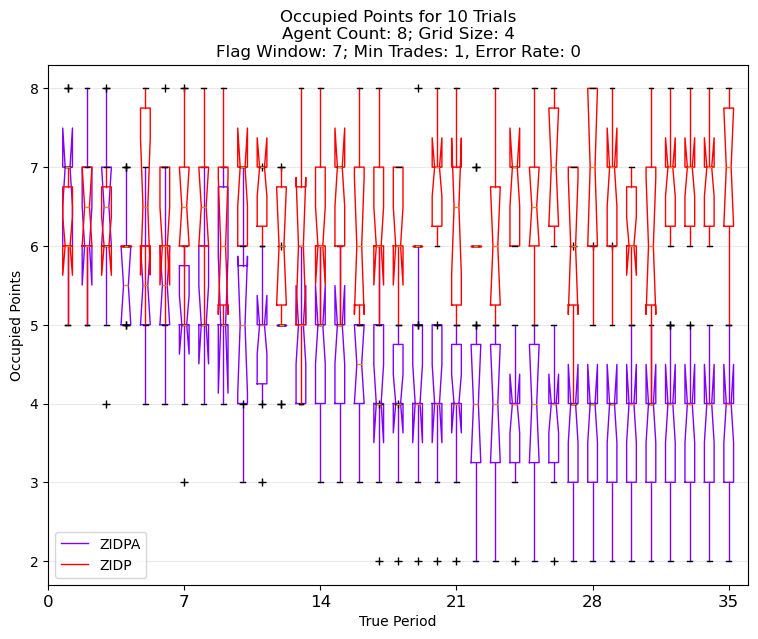

<Figure size 640x480 with 0 Axes>

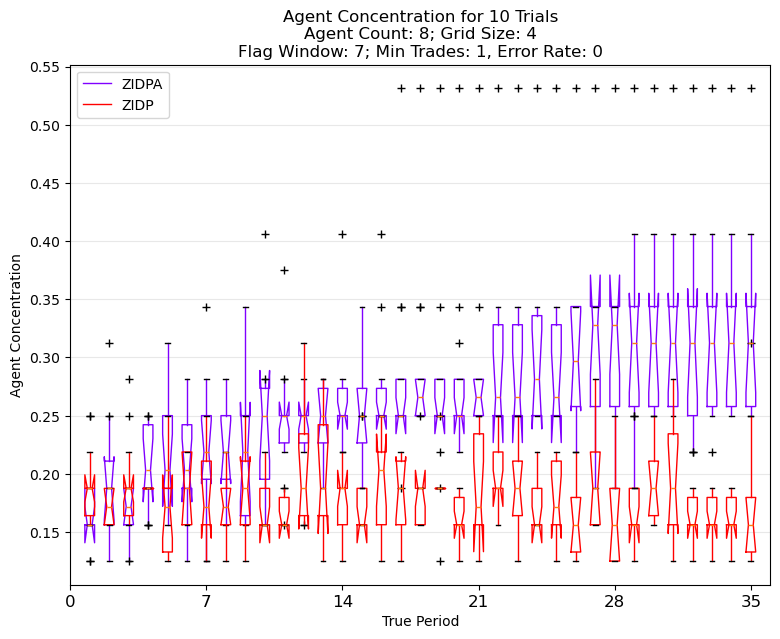

<Figure size 640x480 with 0 Axes>

In [37]:
s1_e = add_period_efficiency(s1, s1_p)
s1_tp = add_true_period(s1_e)
s1_tp_c = add_period_volume(s1_tp)
s1_tp_cn = agent_density(s1_tp_c, by_period=True, return_df=True)

s1_pr = trim_initial_locations(s1_tp_c)
s1_pr = add_period_price(s1_p)
s1_pd = add_location_prices(s1_pr)
s1_wd_gen, s1_ret_wd_gen = add_week_prices(s1_pd, return_sep_df=True)
s1_wd, s1_retw = add_week_location_prices(s1_pd, return_sep_df=True)

s2_e = add_period_efficiency(s2, s2_p)
s2_tp = add_true_period(s2_e)
s2_tp_c = add_period_volume(s2_tp)
s2_tp_cn = agent_density(s2_tp_c, by_period=True, return_df=True)

s2_pr = trim_initial_locations(s2_tp_cn)
s2_pr = add_period_price(s2_pr)
s2_pd = add_location_prices(s2_pr)
s2_wd_gen, s2_ret_wd_gen = add_week_prices(s2_pd, return_sep_df=True)
s2_wd, s2_retw = add_week_location_prices(s2_pd, return_sep_df=True)

num_true_periods = num_weeks*num_periods
incr = num_periods

s1_tp_n = format_df_for_boxplot(s1_tp_cn, 'tr_period', 'loc_occupied')
s2_tp_n = format_df_for_boxplot(s2_tp_cn, 'tr_period', 'loc_occupied')
ttl = f"Occupied Points for {num_trials} Trials\nAgent Count: {num_traders}; Grid Size: {grid_size}\nFlag Window: {window_size}; Min Trades: {min_trades}, Error Rate: {movement_error_rate}"
plot_boxplot_data([s1_tp_n, s2_tp_n], title=ttl, y_lab="Occupied Points", x_lab="True Period", x_ticks=np.arange(0, num_true_periods+1, incr), rbars=None, savename=None, legend=True, n=2, labels=["ZIDPA", "ZIDP"], xlim=(0,num_true_periods+1))

s1_tp_h = format_df_for_boxplot(s1_tp_cn, 'tr_period', 'agent_conct')
s2_tp_h = format_df_for_boxplot(s2_tp_cn, 'tr_period', 'agent_conct')
ttl = f"Agent Concentration for {num_trials} Trials\nAgent Count: {num_traders}; Grid Size: {grid_size}\nFlag Window: {window_size}; Min Trades: {min_trades}, Error Rate: {movement_error_rate}"
plot_boxplot_data([s1_tp_h, s2_tp_h], title=ttl, y_lab="Agent Concentration", x_lab="True Period", x_ticks=np.arange(0, num_true_periods+1, incr), rbars=None, savename=None, legend=True, n=2, labels=["ZIDPA", "ZIDP"], xlim=(0,num_true_periods+1))



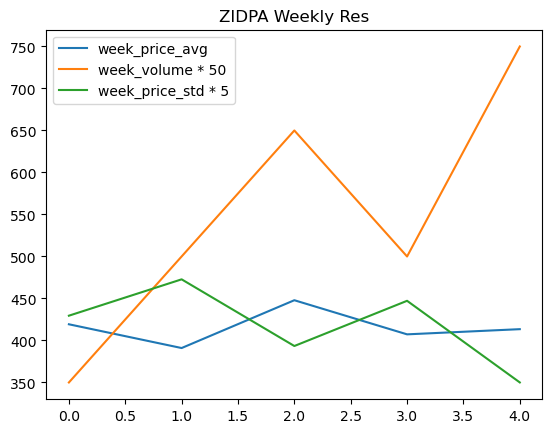

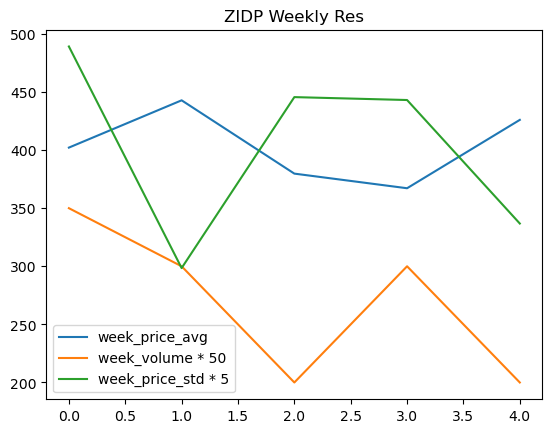

In [38]:
plt.figure()
plt.title("ZIDPA Weekly Res")
plt.plot(s1_ret_wd_gen[s1_ret_wd_gen['trial']==0]['week_price_avg'], label="week_price_avg")
plt.plot(s1_ret_wd_gen[s1_ret_wd_gen['trial']==0]['week_volume']*50, label="week_volume * 50")
plt.plot(s1_ret_wd_gen[s1_ret_wd_gen['trial']==0]['week_price_std']*5, label="week_price_std * 5")
plt.legend()

plt.figure()
plt.title("ZIDP Weekly Res")
plt.plot(s2_ret_wd_gen[s2_ret_wd_gen['trial']==0]['week_price_avg'], label="week_price_avg")
plt.plot(s2_ret_wd_gen[s2_ret_wd_gen['trial']==0]['week_volume']*50, label="week_volume * 50")
plt.plot(s2_ret_wd_gen[s2_ret_wd_gen['trial']==0]['week_price_std']*5, label="week_price_std * 5")
plt.legend()

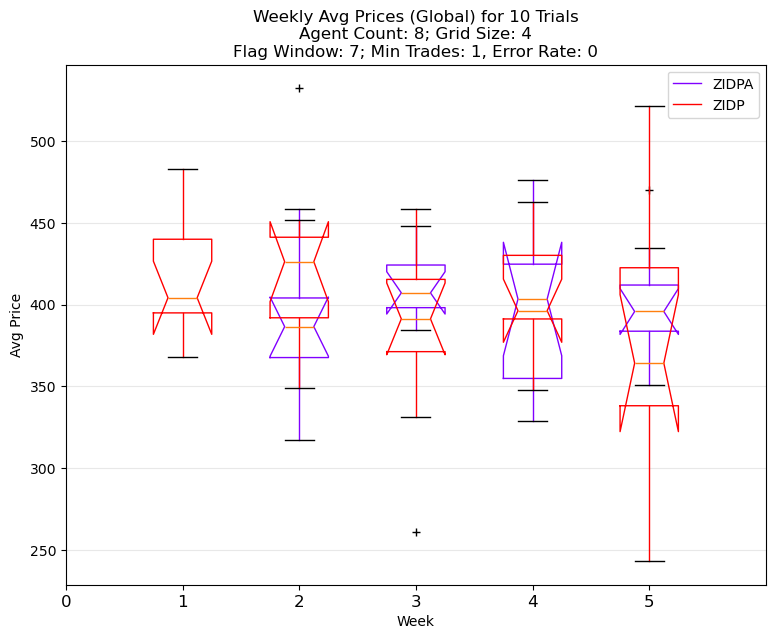

<Figure size 640x480 with 0 Axes>

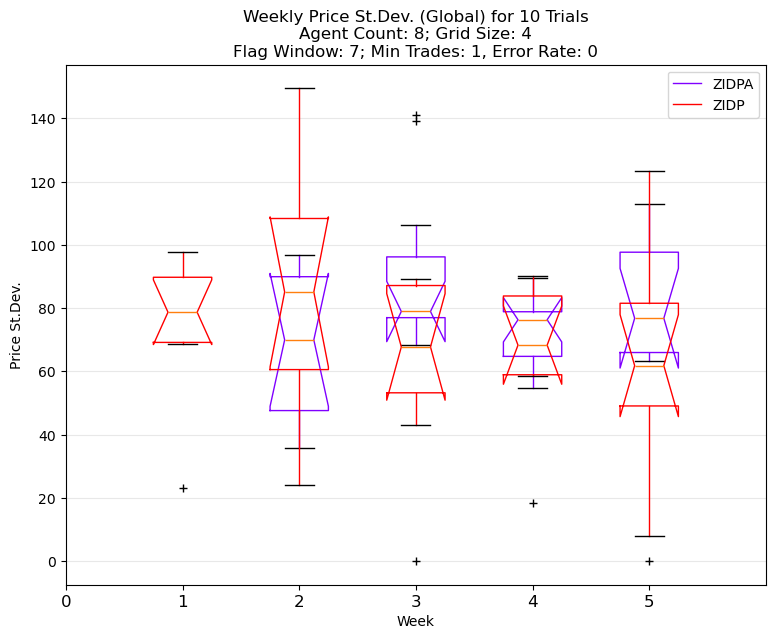

<Figure size 640x480 with 0 Axes>

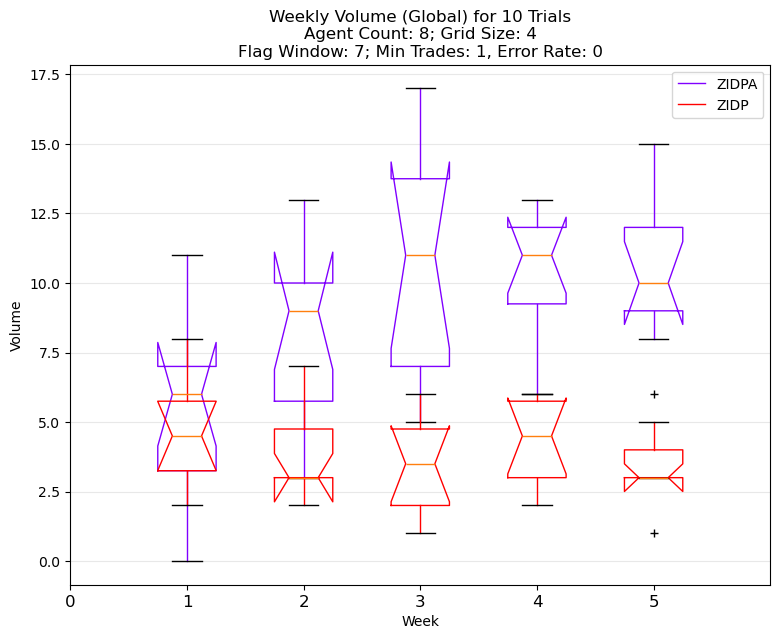

<Figure size 640x480 with 0 Axes>

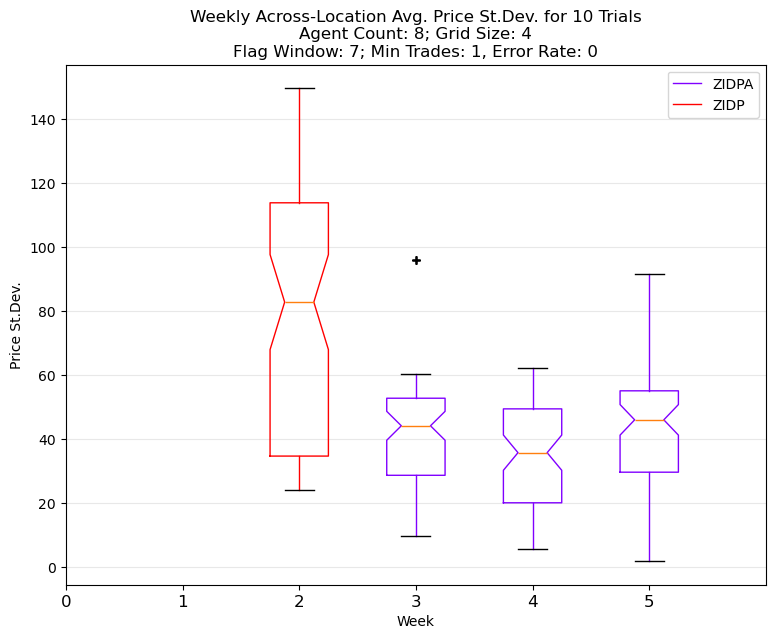

<Figure size 640x480 with 0 Axes>

In [39]:
incr = 1

# Week-Based Observations - Prices
zidpa_pas = format_df_for_boxplot(s1_ret_wd_gen, 'week', 'week_price_avg')
zidp_pas = format_df_for_boxplot(s2_ret_wd_gen, 'week', 'week_price_avg')

ttl = f"Weekly Avg Prices (Global) for {num_trials} Trials\nAgent Count: {num_traders}; Grid Size: {grid_size}\nFlag Window: {window_size}; Min Trades: {min_trades}, Error Rate: {movement_error_rate}"
plot_boxplot_data([zidpa_pas, zidp_pas], title=ttl, y_lab="Avg Price", x_lab="Week", x_ticks=np.arange(0, num_weeks+1, incr), rbars=None, savename=None, legend=True, n=2, labels=["ZIDPA", "ZIDP"], xlim=(0, num_weeks+1))

# Standard Deviation (global)
zidpa_std = format_df_for_boxplot(s1_ret_wd_gen, 'week', 'week_price_std')
zidp_std = format_df_for_boxplot(s2_ret_wd_gen, 'week', 'week_price_std')

ttl = f"Weekly Price St.Dev. (Global) for {num_trials} Trials\nAgent Count: {num_traders}; Grid Size: {grid_size}\nFlag Window: {window_size}; Min Trades: {min_trades}, Error Rate: {movement_error_rate}"
plot_boxplot_data([zidpa_std, zidp_std], title=ttl, y_lab="Price St.Dev.", x_lab="Week", x_ticks=np.arange(0, num_weeks+1, incr), rbars=None, savename=None, legend=True, n=2, labels=["ZIDPA", "ZIDP"], xlim=(0, num_weeks+1))

# Volume
zidpa_vol = format_df_for_boxplot(s1_ret_wd_gen, 'week', 'week_volume')
zidp_vol = format_df_for_boxplot(s2_ret_wd_gen, 'week', 'week_volume')

ttl = f"Weekly Volume (Global) for {num_trials} Trials\nAgent Count: {num_traders}; Grid Size: {grid_size}\nFlag Window: {window_size}; Min Trades: {min_trades}, Error Rate: {movement_error_rate}"
plot_boxplot_data([zidpa_vol, zidp_vol], title=ttl, y_lab="Volume", x_lab="Week", x_ticks=np.arange(0, num_weeks+1, incr), rbars=None, savename=None, legend=True, n=2, labels=["ZIDPA", "ZIDP"], xlim=(0, num_weeks+1))

# Across-Location Standard Deviation (Price Fragmentations)
zidpa_cl = format_df_for_boxplot(s1_wd, 'week', 'week_loc_cross_std')
zidp_cl = format_df_for_boxplot(s2_wd, 'week', 'week_loc_cross_std')

ttl = f"Weekly Across-Location Avg. Price St.Dev. for {num_trials} Trials\nAgent Count: {num_traders}; Grid Size: {grid_size}\nFlag Window: {window_size}; Min Trades: {min_trades}, Error Rate: {movement_error_rate}"
plot_boxplot_data([zidpa_cl, zidp_cl], title=ttl, y_lab="Price St.Dev.", x_lab="Week", x_ticks=np.arange(0, num_weeks+1, incr), rbars=None, savename=None, legend=True, n=2, labels=["ZIDPA", "ZIDP"], xlim=(0, num_weeks+1))

In [40]:
def calc_area_under_curve(simulation_df, metric="eff", metric_max=100):
    """Calculates the area under the curve = sum of efficiencies/sum(max efficiencies) for a particular run or set of runs - returns 1 number or df of trials: areas"""
    num_trials = simulation_df['num_trials'].valuess[0]

    if num_trials == 1:
        return simulation_df[metric].sum()/(simulation_df['num_weeks']*metric_max)
    else:
        ret_df = simulation_df.groupby('trial').sum(metric)/(simulation_df['num_weeks']*metric_max)
        return ret_df.reset_index()

def conduct_stat_test(measure_a, measure_b, test_method, hypothesis_sidedness="one", measure_list=None):
    if measure_a is None and measure_b is None:
        measure_a = measure_list[0]; measure_b = measure_list[1]
    ci = None
    if test_method == "t":
        t_res = scipy.stats.ttest_ind(measure_a, measure_b, alternative=f"{hypothesis_sidedness}-sided")
        test_val = t_res.statistic
        p_val = t_res.pvalue
        ci = t_res.confidence_interval()
    elif test_method == "mwu":
        mwu_res = scipy.stats.mannwhitneyu(measure_a, measure_b, alternative=f"{hypothesis_sidedness}-sided")
        test_val = mwu_res.statistic
        p_val = mwu_res.pvalue
    elif test_method == "kruskal":
        k_res = scipy.stats.kruskal(measure_a, measure_b)
        test_val = k_res.statistic
        p_val = k_res.pvalue
    elif test_method == "f":
        f_res = scipy.stats.f_oneway(measure_a, measure_b)
        test_val = f_res.statistic
        p_val = f_res.pvalue
    elif test_method == "ks":
        ks_res = scipy.stats.ks_2samp(measure_a, measure_b, alternative=f"{hypothesis_sidedness}-sided")
        test_val = ks_res.statistic
        p_val = ks_res.pvalue
    elif test_method == "page":
        p_res = scipy.stats.page_trend_test(reversed(measure_list))
        test_val = p_res.statistic
        p_val = p_res.pvalue
    
    # Return test statistic, p-value for 2-sided test, and confidence interval
    return test_val, p_val, ci

def aggregate_obs(df, aggregation_method, metric, observation_frequency, measure_frequency):
    """Aggregate measures up to the observation frequency"""
    if aggregation_method == "mean":
        df_ret = df[['trial', measure_frequency, observation_frequency, metric]].groupby(by=['trial', observation_frequency]).mean().reset_index()
    elif aggregation_method == "median":
        df_ret = df[['trial', measure_frequency, observation_frequency, metric]].groupby(by=['trial', observation_frequency]).median().reset_index()
    if aggregation_method == "end":
        max_trials = max(df[measure_frequency])
        df_ret = df[df[measure_frequency] == max_trials]
    return df_ret

def calc_diff(df_a, df_b, metric, measure_method="mean", test_method="ks", compare_method="across", observation_frequency="week", measure_frequency="week", aggregation_method="mean", weeks="all", tr_periods=None, hypothesis_sidedness="two", metric_max=None):
    """Calculate differences between two dataframes, comparing the desired metric.
    df_a, df_b  - simulation dataframes to difference; df_a should have a higher (>=) expected measure of the metric. I.e. if testing one-sided hypotheses, pass df_a as the x > u. (simply by convention)
    metric - Metric to compare across simulations, Ex: "eff" (efficiency)
    
    measure_method (str) - choose one of the options in which to handle the calculation of the desired metric for differencing. Across options look at one measure per trial, returning a measure, a std. err., and a p-value; within options look at one measure per frequency (week or period) per trial, returning a dataframe with observation count, measure, std. err. (where applicable), and p-value
        - Measure options: "mean" (mean measure across weeks/periods), "auc" (area under curve - similar to mean), "median" (median of measure across), "end" (single measure is final observation) - how to select the measure of each trial (only used in "across")
    
    test_method (str) - Test options: "ks" (kolmogorov-smirnov test), "mwu" (mann-whitney-u test), "t" (t-test) - the statistical test to perform

    compare_method (str) - Compare options: "across", "within" - if comparison is an "across" (one measure per trial) or a "within" (measures = number of frequency appearances)
    
    observation_frequency - "week" or "period" - at what aggregation (default by mean) observation level to conduct "within" option tests. Must have added true period column to use "period" frequency.
    measure_frequency - the frequency with which the metric is observed in the dataframe. Ignored if equivalent to the "frequency"
    aggregation_method - "mean" or "median" - how to aggregate period-level observation up to "week" level if frequency is "week" and "obsevation_frequency" is at the "period" level.
    weeks = "all" or tuple (start, end) - specify over which weeks to calculate the comparison. If not specified, defaults to "all" weeks.
    tr_periods (tuple) or "all": (start, end) - specify over which true periods (cross-week indexed) to caculate the metric. Must specify if asking for a frequency of "period". "all" means all periods.
    # TODO implement subsets for weeks and tr_periods
    hypothesis_sidedness (str) - "one", "two", or "order" - one sided, two sided, or ordered (Jonkheere Terpstra)
    metric_max (float) - the maximum that the observation can be at any point - used for AUC calculation
    """

    if measure_method == "auc" and metric_max is None:
        raise ValueError("Need to pass a metric max for AUC calculation.")

    if test_method == "page":
        if type(df_a) is not list or df_b is not None:
            raise ValueError("For df_a pass a list of dataframes, with expected largest on the left, down to df_n (ordered expectations). Pass df_b as none.")
        df_s = df_a
    else:
        df_s = [df_a, df_b]

    # Check if can check the sidedness
    if hypothesis_sidedness == "order" and test_method != "page":
        raise ValueError("Need to use the Page Trend (page) test for the order sidedness.")

    try:
        for df in df_s:
            df[metric]
    except KeyError:
        raise ValueError("The metric is not containted within at least one of the passed dataframes.")
    
    if observation_frequency == "period" or measure_frequency == "period":
        if observation_frequency == "period" and not measure_frequency == "period": raise ValueError("Cannot disaggregate measure frequency. Check you indicate measure frequency as period is you want period-to-period measures.")
        try:
            for df in df_s:
                df['tr_period']
        except:
            raise ValueError("At least one of the dataframes does not have the tr_period column, required for period-level analysis.")
    
    if observation_frequency == "week" and measure_frequency == "period":
        for df_i in range(len(df_s)):
            this_df = df_s[df_i]
            this_df = aggregate_obs(this_df, aggregation_method, metric, observation_frequency, "tr_period")
    
    if hypothesis_sidedness == "one" and test_method in ["kruskal", "f"]:
        raise ValueError("Cannot use one-sided hypothesis test with this test type.")

    if weeks != "all":
        for df_i in range(len(df_s)):
            this_df = df_s[df_i]
            this_df = this_df[(this_df['week'] >= weeks[0]) & (this_df['week'] <= weeks[1])]    

    if tr_periods != "all":
        for df_i in range(len(df_s)):
            this_df = df_s[df_i]
            this_df = this_df[(this_df['tr_period'] >= tr_periods[0]) & (this_df['tr_period'] <= tr_periods[1])]

    if observation_frequency == "week":
        obs_freq = observation_frequency 
    elif observation_frequency == "period":
        obs_freq = "tr_period"

    # Single measure methods
    if compare_method == "across":
        measure_list = []
        for df_i in range(len(df_s)):
            this_df = df_s[df_i]
            if measure_method == "mean": # Mean of periods
                measure_list.append(this_df[['trial', observation_frequency, metric]].groupby(by=['trial']).mean().reset_index()[metric])
                
            elif measure_method == "median": # Median of periods
                measure_list.append(this_df[['trial', observation_frequency, metric]].groupby(by=['trial']).median().reset_index()[metric])
            
            elif measure_method == "end": # Last period
                final_period = max(this_df[obs_freq])
                measure_list.append(this_df[this_df[obs_freq]==final_period][['trial', metric]].copy()[metric])
            
            elif measure_method == "auc": # Area under curve (= mean deviation from max)
                measure_list.append(calc_area_under_curve(this_df, metric, metric_max=metric_max)[metric])

        test_stat, p_val, ci = conduct_stat_test(measure_a=None, measure_b=None, test_method=test_method, hypothesis_sidedness=hypothesis_sidedness, measure_list=measure_list)

        return test_stat, p_val, ci

    # Many measure methods
    elif compare_method == "within":
        ret_df = None
        for i in range(max(df_s[0][obs_freq])+1):
            measure_list = []
            for df_i in range(len(df_s)):
                this_df = df_s[df_i]
                mes = this_df[this_df[obs_freq]==i][metric]
                measure_list.append(mes)
            
            test_stat, p_val, ci = conduct_stat_test(measure_a=None, measure_b=None, test_method=test_method, hypothesis_sidedness=hypothesis_sidedness, measure_list=measure_list)
            tr_df = pd.DataFrame({obs_freq:[i], 'statistic':[test_stat], 'p_value':[p_val], 'confidence_interval':[ci]})
            
            if ret_df is None:
                ret_df = tr_df
            else:
                ret_df = pd.concat([ret_df, tr_df], ignore_index=True)
        return ret_df


In [41]:
def match_density(period_locs, true_match=False, agent_types=('B','S'), by_locs=False, max_match=None):
    """
    Implemented for 1 and multiple types of agents.
    
    true_match (boolean): default False. True match only counts TRUE matches - so if there is an exact match between the agent types, dropping the remainder. - E.g. if there are 2 agent types a match counts as 1 if there is 1 of type B and one of S, but if there are 2 of type B, there is 0 match. A point with 2 B and 1 S would also be a measure of 1. FALSE: San have false matches, discounting unclean matches If there are 1 of B and 2 of S, it counts as 1.5. If there are 1 of B and 3 of S, it will count as 1.75, so each S unmatched will count as (1/max_match)^n, where n is the number of unmatched S. A point with 2 B would count as 0.75 of a match, and 1 B would be 0.5.

    by_locs (boolean): default False. If want to return the match density by location. Only returns non-zero density locations. Otherwise returns overall match density. 

    """

    loc_match_d = []
    all_match_d = 0

    # Set the max_match (maximizing value fo match) if not passed
    if max_match is None:
        # 2 is the perfect match in 1 type - by assumption, can pass alternative - pass 1 if no such metric exists
        if len(agent_types):
            max_match = 2
        # Num agent types is the perfect match by assumption
        else:
            max_match = len(agent_types)
        
    
    for lc in period_locs:
        ags = period_locs[lc]
        n_ags = len(ags)
        if n_ags <= 1 and true_match: # If only one agent at point, cannot have a true match
            continue
        else:
            if len(agent_types) == 1:
                if true_match:
                    obs_d = n_ags//max_match 
                else:
                    tr_match = n_ags//max_match # Full matches
                    rem = n_ags%max_match
                    rem_arr = np.arange(1, rem+1)
                    part_val = 1/max_match
                    rem_val = np.sum(np.power(part_val, rem_arr)) # Value of partial matches
                    obs_d = tr_match + rem_val
            else:
                # Count agents per types
                type_obs = dict()
                for typ in agent_types:
                    type_obs[typ] = 0
                for ag in ags:
                    ag_typ = ag[0] # Agent type is indicated by the first character of their name
                    type_obs[ag_typ] += 1
                
                # Count matches
                min_of_types = None
                max_of_types = None
                for typ in agent_types:
                    ag_n = type_obs[typ]

                    # Record min of agents in type
                    if min_of_types is None:
                        min_of_types = ag_n
                    elif ag_n < min_of_types:
                        min_of_types = ag_n

                    # Record max of agents in type
                    if max_of_types is None:
                        max_of_types = ag_n
                    elif ag_n > max_of_types:
                        max_of_types = ag_n
                
                tr_match = min_of_types # True match count = lowest type count

                if true_match or max_of_types == min_of_types:
                    obs_d = tr_match
                else:
                    # Calculate the remainder values
                    part_val = 1/max_match
                    rem_val = 0
                    for typ in agent_types:
                        rem_ags = type_obs[typ] - min_of_types
                        if rem_ags == 0:
                            continue
                        rem_arr = np.arange(1, rem_ags+1)
                        r_val = np.sum(np.power(part_val, rem_arr)) # Value of the remainder of this type of agent
                        rem_val += r_val
                    obs_d = tr_match + rem_val

        if not obs_d == 0:
            all_match_d += obs_d
            loc_match_d.append((lc, obs_d))
    
    if by_locs:
        return tuple(loc_match_d) # Tuple of form ((location, density), ...)
    else:
        return all_match_d

In [42]:
s1_wd['md_test'] = s1_wd.period_locs.apply(match_density)
s1_wd['md_test_loc'] = s1_wd.period_locs.apply(match_density, args=[False, ('B','S'), True, None])
s1_wd['md_test_true'] = s1_wd.period_locs.apply(match_density, args=[True, ('B','S'), False, None])
s1_wd['md_test_third'] = s1_wd.period_locs.apply(match_density, args=[False, ('T'), False, 3])

In [43]:
s1_wd.period_locs.iloc[175]

{(0, 2): ['B_1_ZIDPA'],
 (3, 1): ['B_2_ZIDPA', 'S_3_ZIDPA'],
 (2, 2): ['B_3_ZIDPA'],
 (1, 2): ['B_4_ZIDPA'],
 (3, 2): ['S_1_ZIDPA'],
 (2, 3): ['S_2_ZIDPA'],
 (3, 3): ['S_4_ZIDPA']}

In [44]:
s1_wd['md_test'].iloc[175]

4.0

In [45]:
s1_wd['md_test_true'].iloc[175]

1

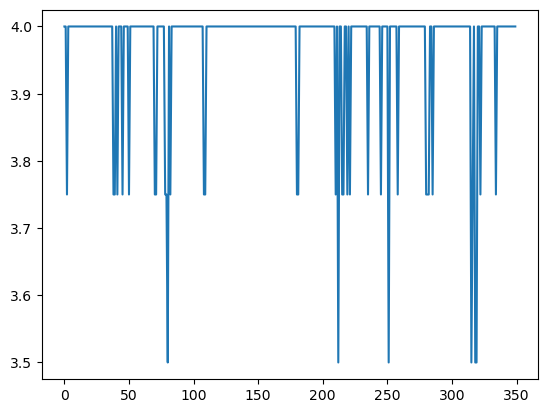

In [51]:
plt.plot(s1_wd.md_test)

In [52]:
# match_density(period_locs, true_match=False, agent_types=('B','S'), by_locs=False, max_match=None):
s1_wd.period_locs.apply(match_density).unique()

array([4.  , 3.75, 3.5 ])

In [53]:
d_lc = s1_wd.period_locs.iloc[0]

for lc in d_lc:
    print(lc, "at", d_lc[lc][0][0])

(0, 0) at B
(1, 0) at B
(2, 1) at S
(2, 2) at B
(1, 2) at S
(3, 1) at S
(0, 1) at S


In [49]:
# TODO add location-level efficiency
# TODO add location-level match density - num_sellers * num_buyers .... return to this in a sec
metric_maxes = {'eff': 100, 'period_volume': df_s[i]['num_traders'].iloc[0] * df_s[i]['num_'].iloc[0], 'loc_occupied': df_s[i]['num_traders'].iloc[0], 'agent_conct': 1}
m_max = metric_maxes[metric]

week_metrics = ['eff', 
                'week_price_avg', 'week_price_std', 'week_volume', 
                'week_loc_occupied', 'week_agent_conct'] # , 'week_loc_cross_std'] - excluded because almost always 0
period_metrics = ['price_avg', 'price_std', 'period_volume', 'loc_occupied', 'agent_conct', ]

calc_diff(test_a, test_b, metric='metric', 
          measure_method='mean', test_method='t', compare_method='across',
          observation_frequency='week', measure_frequency='period', aggregation_method='mean', # TODO rename frequency = obs freq, obs freq = measure freq TODO add end agg method
          weeks='all', tr_periods='all', hypothesis_sidedness='two') # TODO add one-sided option

NameError: name 'df_s' is not defined

In [ ]:
test_a = pd.DataFrame({'trial':[0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2], 
                       'week': [0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1], 
                       'tr_period':[0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3], 
                       'metric':[10, 10, 20, 2000, 20, 20, 40, 4000, 30, 30, 60, 6000]})
test_b = pd.DataFrame({'trial':[0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2], 
                       'week': [0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1], 
                       'tr_period':[0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3], 
                       'metric':[5, 5, 10, 1000, 10, 10, 20, 2000, 20, 20, 30, 5000000000000]})

(np.float64(-0.99999999847),
 np.float64(0.3739009669569263),
 ConfidenceInterval(low=np.float64(-1573518792735.4487), high=np.float64(740185460920.4487)))

In [ ]:
calc_diff(test_a, test_b, metric='metric', 
          measure_method='median', test_method='f', compare_method='within',
          observation_frequency='week', measure_frequency='period', aggregation_method='mean',
          weeks='all', tr_periods='all', hypothesis_sidedness='two') 

# TODO expand to have multiple hypothesis adjustment
# TODO add measure of concentration with Buyer/Seller
# TODO add measure of average prices

,week,statistic,p_value,confidence_interval
0,0,1.315789,0.315296,None
1,1,1.000000,0.332195,None


In [ ]:
agg_a = test_a[['trial', 'tr_period', 'week', 'metric']].groupby(by=['trial', 'week']).mean().reset_index()
m_a = agg_a.groupby(by=['trial']).mean().reset_index()
m_a.head()

,trial,week,tr_period,metric
0,0,0.5,1.0,343.333333
1,1,0.5,1.0,686.666667
2,2,0.5,1.0,1030.000000


In [ ]:
agg_a = test_a[['trial', 'tr_period', 'week', 'metric']].groupby(by=['trial', 'week']).median().reset_index()
agg_a.head()

,trial,week,tr_period,metric
0,0,0,0.0,10.0
1,0,1,2.0,20.0
2,1,0,0.0,20.0
3,1,1,2.0,40.0
4,2,0,0.0,30.0


In [ ]:
type([agg_a]) is list

True

In [ ]:
# TODO: Want to make the num_traders and trader_objects be less onerous to work with - currently have an issue where it appears to been to be double nested

compare_small_flags_wide = True
sg_draw_graphs = False
sg_calc_diffs = True
run_within_tests = True
if compare_small_flags_wide:
    num_trials = 10
    num_periods = 7; num_weeks = 8; num_rounds = 1
    event_begin = 100000000; event_end = 1000000; # == Never event
    num_units = 8; lower_bound = 200; upper_bound = 600 # Trader supply/demand parameters - 4 trades / week / trader is perfect clearing
    movement_error_rate = 0 # A random chance to move away exogenous to movement strategy
    compliance_rate = 1 # How many traders follow restrictions during event

    reset_freq = "WINDOW" # Movement strategy employed
    min_agents = None # Min number of agents to stick
    on_random = True # Reset your trade strategy after exogenous move

    if sg_calc_diffs:
        # Table results folder
        sav_fold_t = "small_grid_tests_calc"
        if not os.path.isdir(sav_fold_t): os.mkdir(sav_fold_t)
        sav_name_t = os.path.join(sav_fold_t, f"stats_differences_")

        # To save across frequency measures
        across_result = None
        cross_sav_name = sav_name_t + "across.csv"
        
        # To save within frequency measures
        if run_within_tests:
            within_result = None
            within_sav_name = sav_name_t + "within.csv"

    for w_sz in [1, 3, 5, 7, 9]:
        for m_trad in [1, 2, 3]:
            if w_sz < m_trad: continue # Cannot trade more than once per period in model
            for n_ag in [4, 6, 8]:
                for g_sz in [4, 5, 6]:
                    window_size = w_sz # Size of window (periods) within which counting trades
                    min_trades = m_trad # Minimum trades in window to stick 
                    num_traders = n_ag; # Number of traders (MUST be even)
                    grid_size = g_sz; # Size of the map

                    # Run simulation for ZIDPA traders
                    zidpa_objects = [(ZIDPA, n_ag),(ZIDP, 0)]
                    zidpa_10, zidpa_10_p = make_event_monte_carlo("zidpa_10", num_trials, num_periods, num_weeks,  
                                                    event_begin, event_end,
                                                    num_rounds, grid_size,
                                                    num_traders, num_units,
                                                    lower_bound, upper_bound,
                                                    zidpa_objects, movement_error_rate, compliance_rate, return_df=True, 
                                                    reset_flag_frequency=reset_freq, reset_flag_min_agents=min_agents, reset_flag_on_random=on_random,
                                                    reset_flag_window=window_size, reset_flag_min_trades=min_trades,
                                                    return_period_df=True)
                    
                    # Run simulation for ZIDP traders
                    zidp_objects = [(ZIDPA, 0),(ZIDP, n_ag)] # TODO fix this

                    zidp_10, zidp_10_p = make_event_monte_carlo("zidp_10", num_trials, num_periods, num_weeks,  
                                event_begin, event_end,
                                num_rounds, grid_size,
                                num_traders, num_units,
                                lower_bound, upper_bound,
                                zidp_objects, movement_error_rate, compliance_rate, return_df=True, 
                                reset_flag_frequency=reset_freq, reset_flag_min_agents=min_agents, reset_flag_on_random=on_random,
                                reset_flag_window=window_size, reset_flag_min_trades=min_trades,
                                return_period_df=True)

                    # Extract additional metrics to simulations - position, concentration of markets
                    zidpa_10_p = add_period_efficiency(zidpa_10, zidpa_10_p)
                    zidpa_10_p = add_true_period(zidpa_10_p)
                    zidpa_10_p = agent_density(zidpa_10_p, by_period=True, return_df=True)
                    
                    zidp_10_p = add_period_efficiency(zidp_10, zidp_10_p)
                    zidp_10_p = add_true_period(zidp_10_p)
                    zidp_10_p = agent_density(zidp_10_p, by_period=True, return_df=True)

                    # Add period volume

                    # Add weekly metrics
                    
                    # Used for graphing results
                    if sg_draw_graphs:
                        # Format data for boxplot display
                        zdipa_pn = format_df_for_boxplot(zidpa_10_p, 'tr_period', 'loc_occupied')
                        zdipa_ph = format_df_for_boxplot(zidpa_10_p, 'tr_period', 'agent_conct')
                        zidpa_eff = format_df_for_boxplot(zidpa_10, 'week', 'eff')

                        zidp_pn = format_df_for_boxplot(zidp_10_p, 'tr_period', 'loc_occupied')
                        zidp_ph = format_df_for_boxplot(zidp_10_p, 'tr_period', 'agent_conct')
                        zidp_eff = format_df_for_boxplot(zidp_10, 'week', 'eff')

                        num_true_periods = num_weeks*num_periods
                        incr = num_periods

                        ttl = f"Occupied Points for {num_trials} Trials\nAgent Count: {num_traders}; Grid Size: {grid_size}\nFlag Window: {window_size}; Min Trades: {min_trades}, Error Rate: {movement_error_rate}"

                        metric = "occ"

                        # Graph results folder
                        sav_fold_g = "small_grid_tests_2"
                        if not os.path.isdir(sav_fold_g): os.mkdir(sav_fold_g)
                        sav_name_g = os.path.join(sav_fold_g, f"{metric}_nagent_{n_ag}_gridsize_{g_sz}_winsz_{w_sz}_mtrad_{m_trad}")
                    
                        g_sav_name = sav_name_g + ".png"
                        plot_boxplot_data([zdipa_pn, zidp_pn], title=ttl, y_lab="Occupied Points", x_lab="True Period", x_ticks=np.arange(0, num_true_periods+1, incr), rbars=None, savename=g_sav_name, legend=True, n=2, labels=["ZIDPA", "ZIDP"], xlim=(0,num_true_periods+1))


                        ttl = f"Agent Density: for {num_trials} Trials\nAgent Count: {num_traders}; Grid Size: {grid_size}\nFlag Window: {window_size}; Min Trades: {min_trades}, Error Rate: {movement_error_rate}"

                        metric = "h"
                        sav_name_g = os.path.join(sav_fold_g, f"{metric}_nagent_{n_ag}_gridsize_{g_sz}_winsz_{w_sz}_mtrad_{m_trad}")

                        g_sav_name = sav_name_g + ".png"
                        plot_boxplot_data([zdipa_ph, zidp_ph], title=ttl, y_lab="Agent H", x_lab="True Period", x_ticks=np.arange(0, num_true_periods+1, incr), rbars=None, savename=g_sav_name, legend=True, n=2, labels=["ZIDPA", "ZIDP"], xlim=(0,num_true_periods+1))

                        # Create plots comparing key metrics for the simulation
                        ttl = f"Agent Count: {num_traders}; Grid Size: {grid_size}\nFlag Window: {window_size}; Min Trades: {min_trades}"

                        incr = 1

                        txt_dsc = f"Number of Trials: {num_trials}\nNumber of Periods (Days): {num_periods}\nNumber of Weeks: {num_weeks}\nEvent Begin: {event_begin}\nEvent End: {event_end}\nNumber of Rounds (Trades/Day): {num_rounds}\nGrid Size: {grid_size}\nNumber of Traders: {num_traders}\nNumber of Units: {num_units}\nLower Bound:{lower_bound}\nUpper Bound: {upper_bound}\nMovement Error Rate: {movement_error_rate}\nEvent Compliance Rate: {compliance_rate}\nReset Flag Rule: {reset_freq}\nFlag Window Size: {window_size}\nFlag Min Agents: {min_agents}\nFlag Min Trades: {min_trades}"

                        metric = "eff"
                        sav_name_g = os.path.join(sav_fold_g, f"{metric}_nagent_{n_ag}_gridsize_{g_sz}_winsz_{w_sz}_mtrad_{m_trad}")

                        g_sav_name = sav_name_g + ".png"
                        plot_boxplot_data([zidpa_eff, zidp_eff], title=ttl, y_lab="Efficiency", x_lab="Week", x_ticks=np.arange(0, num_weeks+1, incr), rbars=None, savename=g_sav_name, legend=True, n=2, labels=["ZIDPA", "ZIDP"], xlim=(0,num_weeks+1), ylim=[0, 100])

                    # Used for statistical results
                    if sg_calc_diffs:
                        # Table results folder
                        sav_fold_t = "small_grid_tests_calc"
                        if not os.path.isdir(sav_fold_t): os.mkdir(sav_fold_t)
                        sav_name_t = os.path.join(sav_fold_t, f"{metric}_nagent_{n_ag}_gridsize_{g_sz}_winsz_{w_sz}_mtrad_{m_trad}")

                        # One-per-trial tests
                        
                        # Weekly Metrics
                        for met in ['eff']:
                            t_method = 
                            
                            # Across
                            across_diff = calc_diff([zdipa_pn, zidp_pn], None, "eff", t_method, )

                            #Within
                            within_diff = # TODO HERE

                        # Period Metrics

                        # Many-per-trial tests
                        if run_within_tests:
                            pass

                    #plt.figtext(1, 0.2, txt_dsc)
                    # print(txt_dsc)

In [ ]:
num_trials=10; num_periods=5; num_weeks=3;  
event_begin=10; event_end=10
num_rounds=1; grid_size=2
num_traders=6; num_units=2
lower_bound=10; upper_bound=100
movement_error_rate=0; compliance_rate=1
n_ag=6
zidp_objects = [(ZIDPA, 0),(ZIDP, n_ag)] # TODO fix this
zidp_10, zidp_10_p = make_event_monte_carlo("zidp_10", num_trials, num_periods, num_weeks,  
                                event_begin, event_end,
                                num_rounds, grid_size,
                                num_traders, num_units,
                                lower_bound, upper_bound,
                                zidp_objects, movement_error_rate, compliance_rate, return_df=True, 
                                reset_flag_frequency=reset_freq, reset_flag_min_agents=min_agents, reset_flag_on_random=on_random,
                                reset_flag_window=window_size, reset_flag_min_trades=min_trades,
                                return_period_df=True)

['zidp_10', 6, 2, 3, 5, 1, 2, 10, 100, [(<class 'environment.dm_agents.ZIDPA'>, 0), (<class 'environment.dm_agents.ZIDP'>, 6)], 0, 1, 10, 10, -1, (), {(1, 1): ['B_1_ZIDP', 'B_2_ZIDP'], (1, 0): ['B_3_ZIDP', 'S_1_ZIDP', 'S_3_ZIDP'], (0, 0): ['S_2_ZIDP']}, None, None, -1, {(1, 1): ['B_1_ZIDP', 'B_2_ZIDP'], (1, 0): ['B_3_ZIDP', 'S_1_ZIDP', 'S_3_ZIDP'], (0, 0): ['S_2_ZIDP']}]
['zidp_10', 6, 2, 3, 5, 1, 2, 10, 100, [(<class 'environment.dm_agents.ZIDPA'>, 0), (<class 'environment.dm_agents.ZIDP'>, 6)], 0, 1, 10, 10, -1, (), {(0, 1): ['B_1_ZIDP'], (0, 0): ['B_2_ZIDP', 'S_1_ZIDP', 'S_3_ZIDP'], (1, 0): ['B_3_ZIDP', 'S_2_ZIDP']}, None, None, -1, {(0, 1): ['B_1_ZIDP'], (0, 0): ['B_2_ZIDP', 'S_1_ZIDP', 'S_3_ZIDP'], (1, 0): ['B_3_ZIDP', 'S_2_ZIDP']}]
['zidp_10', 6, 2, 3, 5, 1, 2, 10, 100, [(<class 'environment.dm_agents.ZIDPA'>, 0), (<class 'environment.dm_agents.ZIDP'>, 6)], 0, 1, 10, 10, -1, (), {(1, 1): ['B_1_ZIDP', 'S_1_ZIDP'], (1, 0): ['B_2_ZIDP', 'B_3_ZIDP'], (0, 1): ['S_2_ZIDP'], (0, 0): ['S

In [ ]:
zidp_10_p.week

0     -1
1      0
2      0
3      0
4      0
      ..
155    2
156    2
157    2
158    2
159    2
Name: week, Length: 160, dtype: int64